### Model Calibration and Validation
For calibrating and validating the collective cell structure model, we analyzed our simulated results as follows:

- First, we import the necessary packages for analyses:

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# import the necessary and needed packages for analyses
import os
import glob
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random, pickle
from matplotlib.patches import Patch, Rectangle
from collections import defaultdict


# Set options to display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#### Experimental data extracted from Chen et al, 2020 using Plotdigitizer

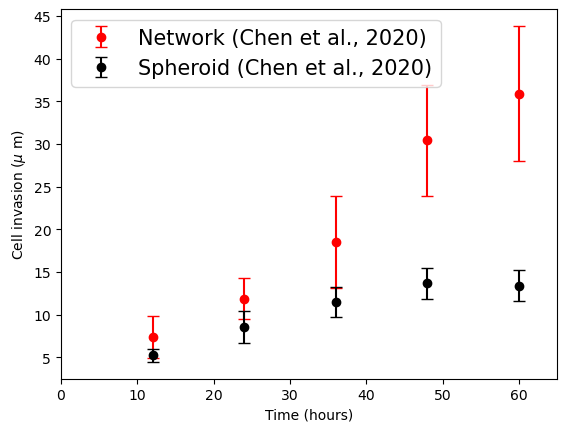

In [3]:
# The data points are extracted from the images using plot digitizer
# Chen Network data
network_hours = [12, 24, 36, 48, 60]
network_invasion = [7.41, 11.88, 18.53, 30.42, 35.91]
network_error = [2.43, 2.43, 5.37, 6.52, 7.92]
plt.errorbar(network_hours, network_invasion, yerr=network_error, color = 'red', fmt='o',capsize=4, label='Network (Chen et al., 2020)')

# Chen Spheroid data
spheroid_hours = [12, 24, 36, 48, 60]
spheroid_invasion = [5.24, 8.56, 11.50, 13.67, 13.42]
spheroid_error = [0.77, 1.92, 1.79, 1.79, 1.79]

# plot the experimental data
plt.errorbar(spheroid_hours, spheroid_invasion, yerr=spheroid_error, color = 'black', fmt='o',capsize=4, label='Spheroid (Chen et al., 2020)')
plt.xlabel('Time (hours)')
plt.ylabel('Cell invasion ($\mu$ m)')
plt.xlim(0, 65)
plt.legend(loc='best', fontsize="15")
plt.savefig("cell_structure_experiment_data.png", dpi = 500, bbox_inches='tight')
plt.show()

In [4]:
exp_data = pd.read_excel("Experimental_Data.xlsx")
exp_data

,Hours,Condition,Invasion,Error
0,12,Network,7.41,2.43
1,24,Network,11.88,2.43
2,36,Network,18.53,5.37
3,48,Network,30.42,6.52
4,60,Network,35.91,7.92
5,12,Spheroid,5.24,0.77
6,24,Spheroid,8.56,1.92
7,36,Spheroid,11.50,1.79
8,48,Spheroid,13.67,1.79
9,60,Spheroid,13.42,1.79


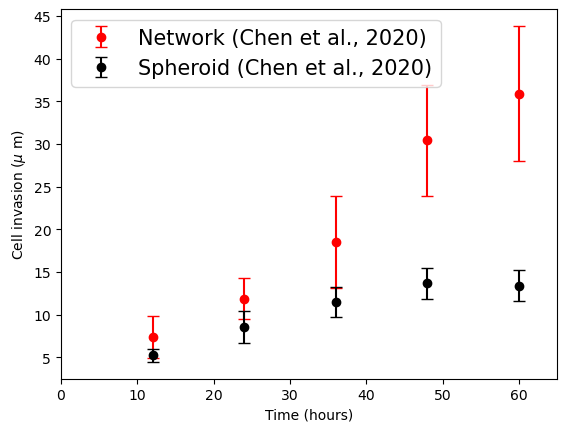

In [5]:
# plot the experimental data
plt.errorbar(exp_data[exp_data["Condition"] == "Network"]["Hours"], exp_data[exp_data["Condition"] == "Network"]["Invasion"], 
             yerr=exp_data[exp_data["Condition"] == "Network"]["Error"], color = 'red', fmt='o',capsize=4, label='Network (Chen et al., 2020)')
plt.errorbar(exp_data[exp_data["Condition"] == "Spheroid"]["Hours"], exp_data[exp_data["Condition"] == "Spheroid"]["Invasion"], 
             yerr=exp_data[exp_data["Condition"] == "Spheroid"]["Error"], color = 'black', fmt='o',capsize=4, label='Spheroid (Chen et al., 2020)')
plt.xlabel('Time (hours)')
plt.ylabel('Cell invasion ($\mu$ m)')
plt.xlim(0, 65)
plt.legend(loc='best', fontsize="15")
plt.savefig("cell_structure_experiment_data.png", dpi = 500, bbox_inches='tight')
plt.show()

### Max cell invasion for experimental data in Chen et al. after 2.5 days (equivalent of 60 hours)

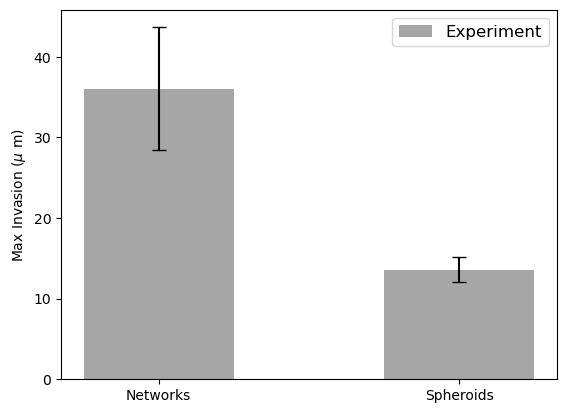

In [6]:
# Provided data (Experiment) using plot digitizer for extraction
labels = ['Networks', 'Spheroids']
experiment_means = [36.03, 13.58]
experiment_errors = [7.63, 1.56]

# Bar positions
x = np.arange(len(labels))  # the label locations
width = 0.5  # the width of the bars

# Create bar chart
fig, ax = plt.subplots()
rects1 = ax.bar(x, experiment_means, width, label='Experiment', yerr=experiment_errors, capsize=5, color='grey', alpha=0.7)


# Add labels 
ax.set_ylabel('Max Invasion ($\mu$ m)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='best', fontsize="12")

# Save and show the plot
plt.savefig("experiment_max_invasion.png", dpi=500, bbox_inches='tight')

### Circularity after 7 days (equivalent of 168 hours)

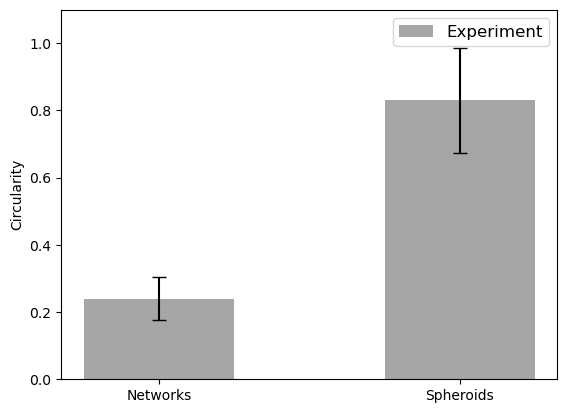

In [7]:
# Provided data (Experiment) through plot digitizer
labels = ['Networks', 'Spheroids']
experiment_means = [0.24, 0.83]
experiment_errors = [0.063, 0.156]

# Bar positions
x = np.arange(len(labels))  # the label locations
width = 0.5  # the width of the bars

# Create bar chart
fig, ax = plt.subplots()
#rects1 = ax.bar(x, experiment_means, width, label='Experiment', capsize=5, color='grey', alpha=0.7)
rects1 = ax.bar(x, experiment_means, width, label='Experiment', yerr=experiment_errors, capsize=5, color='grey', alpha=0.7)


# Add labels
ax.set_ylabel('Circularity')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0,1.1)
ax.legend(loc='best', fontsize="12")

# Save and show the plot
plt.savefig("experiment_circularity.png", dpi=500, bbox_inches='tight')

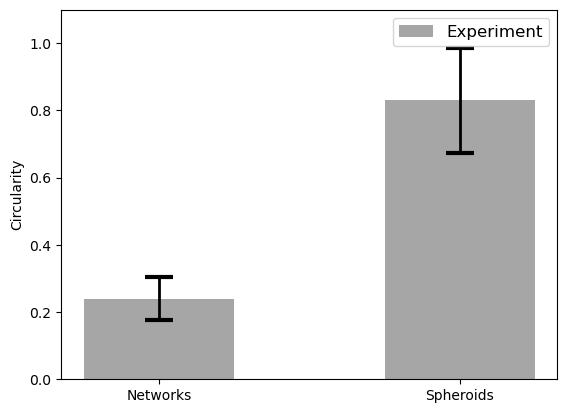

In [8]:
# Provided data (Experiment) through plot digitizer
labels = ['Networks', 'Spheroids']
experiment_means = [0.24, 0.83]
experiment_errors = [0.063, 0.156]

# Bar positions
x = np.arange(len(labels))  # the label locations
width = 0.5  # the width of the bars

# Create bar chart with thick error bars and thick horizontal caps
fig, ax = plt.subplots()
rects1 = ax.bar(
    x, 
    experiment_means, 
    width, 
    label='Experiment', 
    yerr=experiment_errors, 
    capsize=10,  # Length of the cap
    color='grey', 
    alpha=0.7, 
    error_kw={'elinewidth': 2, 'capthick': 3}  # Thickness of error bar and caps
)

# Add labels
ax.set_ylabel('Circularity')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend(loc='best', fontsize="12")

# Save and show the plot
plt.savefig("experiment_circularity.png", dpi=500, bbox_inches='tight')
plt.show()


## Networks and Spheroids data result with Standard deviation

#### Loading cell data:

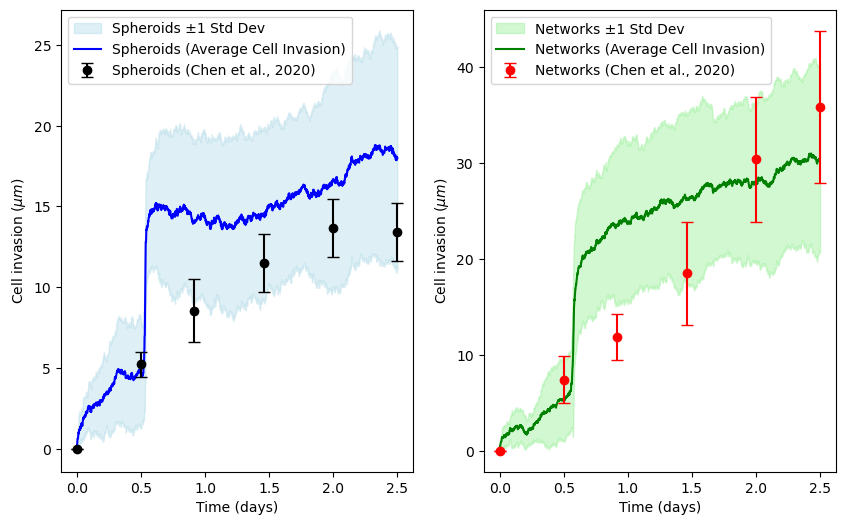

In [9]:
# Function to read and process data from a given folder
def read_and_process_data(folder_path):
    data_list = []

    # Loop through each CSV file and read the data
    # We have 20 replicas for summary statistics and named each celldata1, celldata2,..., celldata20
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        data = pd.read_csv(file_path)
        data_list.append(data)

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Convert MCS to hours (1000 mcs = 1 day) based on experimental setup
    all_data['hours'] = all_data['mcs'] / 1000

    # Multiply cell_invasion by 2 to convert back to the experimental value
    # each cell is 2 μm for 1 pixel in simulation
    all_data['cell_invasion'] *= 2.0

    # Filter data to include only the first 2.5 hours/60 hrs to match experiment
    filtered_data = all_data[all_data['hours'] <= 2.5]

    # Calculate the average and standard deviation for circularity and cell_invasion for each day
    summary_data = filtered_data.groupby('hours').agg({
        'circularity': ['mean', 'std'],
        'cell_invasion': ['mean', 'std']
    }).reset_index()

    # Flatten the column names for clarity
    summary_data.columns = ['hours', 'circularity_mean', 'circularity_std', 'cell_invasion_mean', 'cell_invasion_std']

    return summary_data

# Read and process data from both folders
# summary_data_ec = read_and_process_data('ecc_data1')
# summary_data_sp = read_and_process_data('spp_data')

# summary_data_ec = read_and_process_data('network_1000_10_005')
# summary_data_sp = read_and_process_data('spheroid_1000_10_0005')

#summary_data_ec = read_and_process_data('network_500_25_0001')
#summary_data_sp = read_and_process_data('spheroid_1000_15_0001')

#summary_data_ec = read_and_process_data('network_500_25_005')
#summary_data_sp = read_and_process_data('spheroid_500_10_0005')

summary_data_ec = read_and_process_data('network_335_39_0025')
summary_data_sp = read_and_process_data('spheroid_688_10_00001')

# Experimental data (converted from hours to hours)
network_hours = [0, 12, 22, 35, 48, 60]  # in hours
network_hours = [x / 24 for x in network_hours]  # convert to days
network_conc = [0, 7.41, 11.88, 18.53, 30.42, 35.91]  # Added origin point
network_error = [0, 2.43, 2.43, 5.37, 6.52, 7.92]  # Added origin point

spheroid_hours = [0, 12, 22, 35, 48, 60]  # in hours
spheroid_hours = [x / 24 for x in spheroid_hours]  # convert to days
spheroid_conc = [0, 5.24, 8.56, 11.50, 13.67, 13.42]  # Added origin point
spheroid_error = [0, 0.77, 1.92, 1.79, 1.79, 1.79]  # Added origin point

# Plotting of the images
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# Plot cell_invasion with standard deviation error for spheroid
ax[0].fill_between(summary_data_sp['hours'], 
                   summary_data_sp['cell_invasion_mean'] - summary_data_sp['cell_invasion_std'], 
                   summary_data_sp['cell_invasion_mean'] + summary_data_sp['cell_invasion_std'], 
                   color='lightblue', alpha=0.4, label='Spheroids ±1 Std Dev')
ax[0].plot(summary_data_sp['hours'], summary_data_sp['cell_invasion_mean'], label='Spheroids (Average Cell Invasion)', color='blue')
ax[0].errorbar(spheroid_hours, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', capsize=4, label='Spheroids (Chen et al., 2020)')
ax[0].set_xlabel('Time (days)')
ax[0].set_ylabel('Cell invasion ($ \mu m$)')
ax[0].legend(loc=2)

# Plot cell_invasion with standard deviation error for network
ax[1].fill_between(summary_data_ec['hours'], 
                   summary_data_ec['cell_invasion_mean'] - summary_data_ec['cell_invasion_std'], 
                   summary_data_ec['cell_invasion_mean'] + summary_data_ec['cell_invasion_std'], 
                   color='lightgreen', alpha=0.4, label='Networks ±1 Std Dev')
ax[1].plot(summary_data_ec['hours'], summary_data_ec['cell_invasion_mean'], label='Networks (Average Cell Invasion)', color='green')
ax[1].errorbar(network_hours, network_conc, yerr=network_error, color='red', fmt='o', capsize=4, label='Networks (Chen et al., 2020)')
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Cell invasion ($ \mu m$)')
ax[1].legend()

plt.savefig("cell_invasion_dynamics_combined_std.png", dpi=500, bbox_inches="tight")
plt.show();

#### Combined spheroid and network

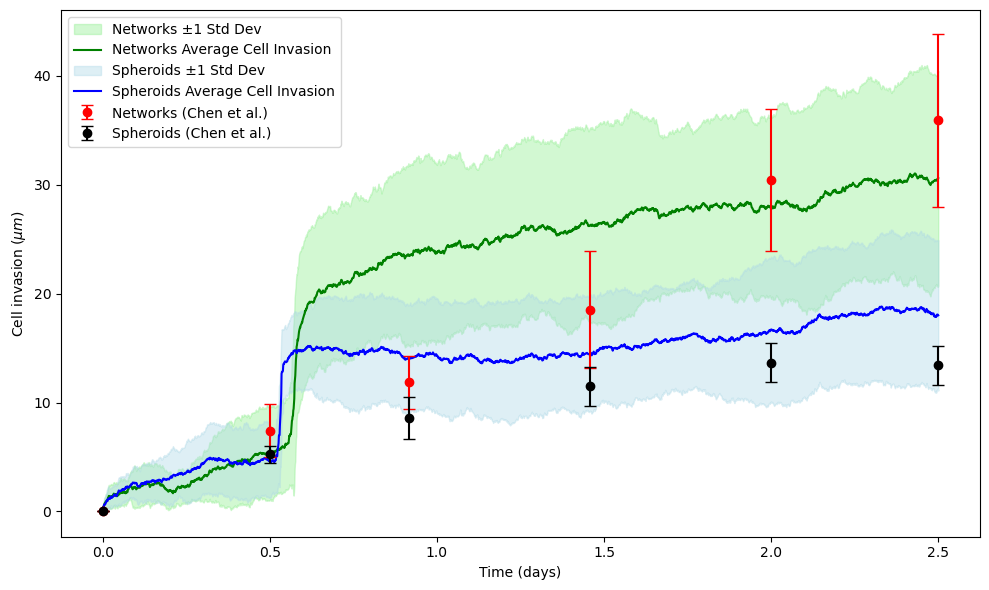

In [10]:
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Fill between ±1 standard deviation for Networks
ax1.fill_between(summary_data_ec['hours'], 
                 summary_data_ec['cell_invasion_mean'] - summary_data_ec['cell_invasion_std'], 
                 summary_data_ec['cell_invasion_mean'] + summary_data_ec['cell_invasion_std'], 
                 color='lightgreen', alpha=0.4, label='Networks ±1 Std Dev')

# Plot the average cell invasion for Networks
ax1.plot(summary_data_ec['hours'], summary_data_ec['cell_invasion_mean'], 
         label='Networks Average Cell Invasion', color='green')

# Fill between ±1 standard deviation for Spheroids
ax1.fill_between(summary_data_sp['hours'], 
                 summary_data_sp['cell_invasion_mean'] - summary_data_sp['cell_invasion_std'], 
                 summary_data_sp['cell_invasion_mean'] + summary_data_sp['cell_invasion_std'], 
                 color='lightblue', alpha=0.4, label='Spheroids ±1 Std Dev')

# Plot the average cell invasion for Spheroids
ax1.plot(summary_data_sp['hours'], summary_data_sp['cell_invasion_mean'], 
         label='Spheroids Average Cell Invasion', color='blue')

# Add error bars for the experimental data
ax1.errorbar(network_hours, network_conc, yerr=network_error, color='red', fmt='o', capsize=4, label='Networks (Chen et al.)')
ax1.errorbar(spheroid_hours, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', capsize=4, label='Spheroids (Chen et al.)')

# Set plot labels and legend
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Cell invasion ($ \mu m$)')
ax1.legend()
plt.tight_layout()

# Save the figure
plt.savefig('cell_invasion_combined_plot_net_sphe_std.png', dpi=500, bbox_inches='tight')
plt.show()

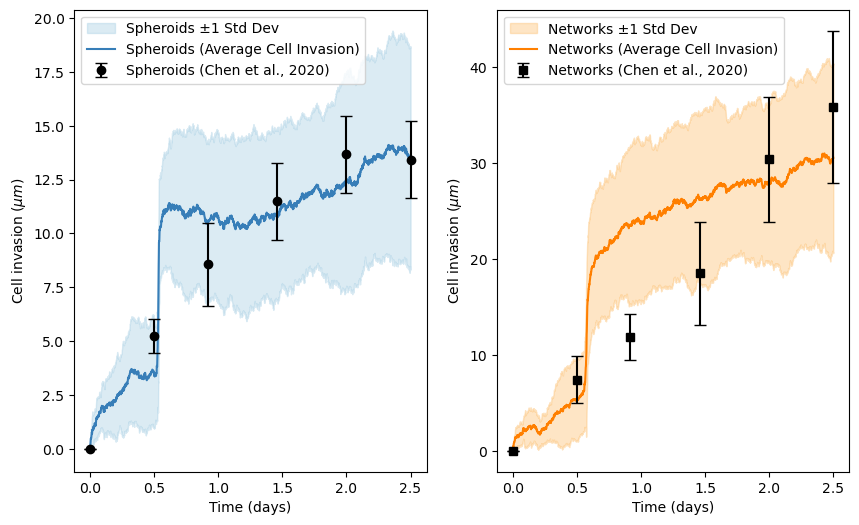

In [11]:
# Function to read and process data from a given folder
def read_and_process_data(folder_path):
    data_list = []

    # Determine phenotype from folder name
    if 'spheroid' in folder_path.lower():
        invasion_multiplier = 1.5
    elif 'network' in folder_path.lower():
        invasion_multiplier = 2.0
    else:
        raise ValueError("Folder name must contain either 'spheroid' or 'network' to determine phenotype type.")

    # Read CSVs celldata1.csv to celldata20.csv
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        data = pd.read_csv(file_path)
        data_list.append(data)

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Convert MCS to hours (1000 MCS = 1 day)
    all_data['hours'] = all_data['mcs'] / 1000

    # Apply appropriate cell_invasion multiplier
    all_data['cell_invasion'] *= invasion_multiplier

    # Filter data to include only up to 2.5 hours (60 hours)
    filtered_data = all_data[all_data['hours'] <= 2.5]

    # Calculate mean and standard deviation
    summary_data = filtered_data.groupby('hours').agg({
        'circularity': ['mean', 'std'],
        'cell_invasion': ['mean', 'std']
    }).reset_index()

    # Flatten column names
    summary_data.columns = [
        'hours', 'circularity_mean', 'circularity_std',
        'cell_invasion_mean', 'cell_invasion_std'
    ]

    return summary_data


# Read and process data from both folders
#summary_data_ec = read_and_process_data('network_1000_10_005')
#summary_data_sp = read_and_process_data('spheroid_1000_10_0005')

#summary_data_ec = read_and_process_data('network_500_25_0001')
#summary_data_sp = read_and_process_data('spheroid_1000_15_0001')

#summary_data_ec = read_and_process_data('network_500_25_005')
#summary_data_sp = read_and_process_data('spheroid_500_10_0005')


summary_data_ec = read_and_process_data('network_335_39_0025')
summary_data_sp = read_and_process_data('spheroid_688_10_00001')

# Experimental data (converted from hours to hours)
network_hours = [0, 12, 22, 35, 48, 60]  # in hours
network_hours = [x / 24 for x in network_hours]  # convert to hours
network_conc = [0, 7.41, 11.88, 18.53, 30.42, 35.91]  # Added origin point
network_error = [0, 2.43, 2.43, 5.37, 6.52, 7.92]  # Added origin point

spheroid_hours = [0, 12, 22, 35, 48, 60]  # in hours
spheroid_hours = [x / 24 for x in spheroid_hours]  # convert to hours
spheroid_conc = [0, 5.24, 8.56, 11.50, 13.67, 13.42]  # Added origin point
spheroid_error = [0, 0.77, 1.92, 1.79, 1.79, 1.79]  # Added origin point

# Plotting of the images
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

# Define color-blind friendly colors
spheroid_color = '#377eb8'  # Blue
spheroid_fill_color = '#a6cee3'  # Light Blue
network_color = '#ff7f00'  # Orange
network_fill_color = '#fdbf6f'  # Light Orange

# Plot cell_invasion with standard deviation error for spheroid
ax[0].fill_between(summary_data_sp['hours'], 
                   summary_data_sp['cell_invasion_mean'] - summary_data_sp['cell_invasion_std'], 
                   summary_data_sp['cell_invasion_mean'] + summary_data_sp['cell_invasion_std'], 
                   color=spheroid_fill_color, alpha=0.4, label='Spheroids ±1 Std Dev')
ax[0].plot(summary_data_sp['hours'], summary_data_sp['cell_invasion_mean'], label='Spheroids (Average Cell Invasion)', color=spheroid_color)
ax[0].errorbar(spheroid_hours, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', marker='o', capsize=4, label='Spheroids (Chen et al., 2020)')
ax[0].set_xlabel('Time (days)')
ax[0].set_ylabel('Cell invasion ($ \mu m$)')
ax[0].legend(loc=2)

# Plot cell_invasion with standard deviation error for network
ax[1].fill_between(summary_data_ec['hours'], 
                   summary_data_ec['cell_invasion_mean'] - summary_data_ec['cell_invasion_std'], 
                   summary_data_ec['cell_invasion_mean'] + summary_data_ec['cell_invasion_std'], 
                   color=network_fill_color, alpha=0.4, label='Networks ±1 Std Dev')
ax[1].plot(summary_data_ec['hours'], summary_data_ec['cell_invasion_mean'], label='Networks (Average Cell Invasion)', color=network_color)
ax[1].errorbar(network_hours, network_conc, yerr=network_error, color='black', fmt='s', marker='s', capsize=4, label='Networks (Chen et al., 2020)')
ax[1].set_xlabel('Time (days)')
ax[1].set_ylabel('Cell invasion ($ \mu m$)')
ax[1].legend()

plt.savefig("cell_invasion_dynamics_combined_std.png", dpi=500, bbox_inches="tight")
plt.show();

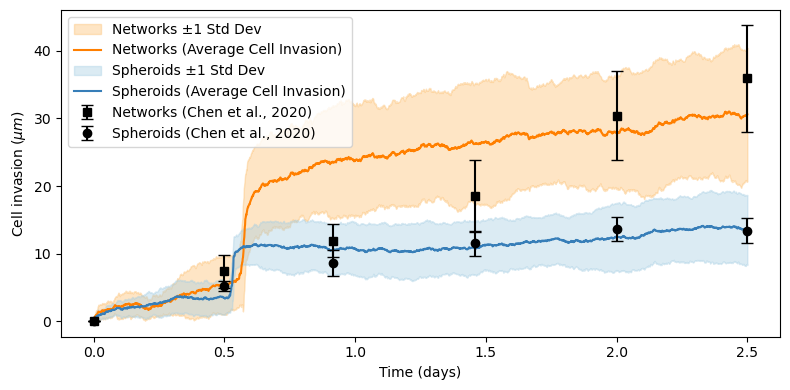

In [12]:
fig1, ax1 = plt.subplots(figsize=(8, 4))

# Define color-blind friendly colors
spheroid_color = '#377eb8'  # Blue
spheroid_fill_color = '#a6cee3'  # Light Blue
network_color = '#ff7f00'  # Orange
network_fill_color = '#fdbf6f'  # Light Orange

# Fill between ±1 standard deviation for Networks
ax1.fill_between(summary_data_ec['hours'], 
                 summary_data_ec['cell_invasion_mean'] - summary_data_ec['cell_invasion_std'], 
                 summary_data_ec['cell_invasion_mean'] + summary_data_ec['cell_invasion_std'], 
                 color=network_fill_color, alpha=0.4, label='Networks ±1 Std Dev')

# Plot the average cell invasion for Networks
ax1.plot(summary_data_ec['hours'], summary_data_ec['cell_invasion_mean'], 
         label='Networks (Average Cell Invasion)', color=network_color)

# Fill between ±1 standard deviation for Spheroids
ax1.fill_between(summary_data_sp['hours'], 
                 summary_data_sp['cell_invasion_mean'] - summary_data_sp['cell_invasion_std'], 
                 summary_data_sp['cell_invasion_mean'] + summary_data_sp['cell_invasion_std'], 
                 color=spheroid_fill_color, alpha=0.4, label='Spheroids ±1 Std Dev')

# Plot the average cell invasion for Spheroids
ax1.plot(summary_data_sp['hours'], summary_data_sp['cell_invasion_mean'], 
         label='Spheroids (Average Cell Invasion)', color=spheroid_color)

# Add error bars for the experimental data with distinct markers
ax1.errorbar(network_hours, network_conc, yerr=network_error, color='black', fmt='s', marker='s', capsize=4, label='Networks (Chen et al., 2020)')
ax1.errorbar(spheroid_hours, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', marker='o', capsize=4, label='Spheroids (Chen et al., 2020)')

# Set plot labels and legend
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Cell invasion ($ \mu m$)')
ax1.legend()
plt.tight_layout()

# Save the figure
plt.savefig('cell_invasion_combined_plot_net_sphe_std.png', dpi=2000, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


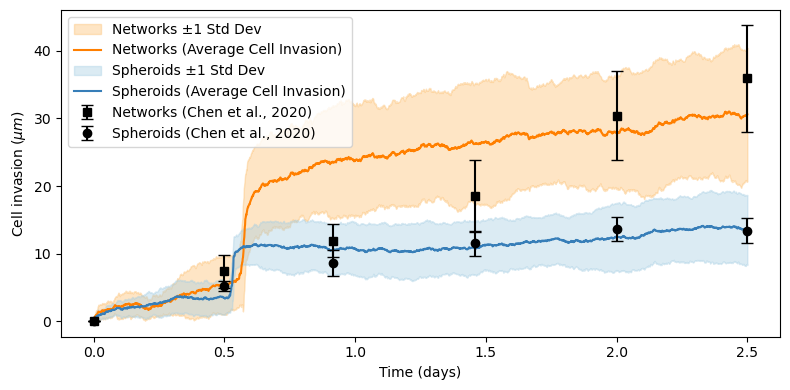

In [13]:
fig1, ax1 = plt.subplots(figsize=(8, 4))

# Define color-blind friendly colors
spheroid_color = '#377eb8'  # Blue
spheroid_fill_color = '#a6cee3'  # Light Blue
network_color = '#ff7f00'  # Orange
network_fill_color = '#fdbf6f'  # Light Orange

# Fill between ±1 standard deviation for Networks
ax1.fill_between(summary_data_ec['hours'], 
                 summary_data_ec['cell_invasion_mean'] - summary_data_ec['cell_invasion_std'], 
                 summary_data_ec['cell_invasion_mean'] + summary_data_ec['cell_invasion_std'], 
                 color=network_fill_color, alpha=0.4, label='Networks ±1 Std Dev')

# Plot the average cell invasion for Networks
ax1.plot(summary_data_ec['hours'], summary_data_ec['cell_invasion_mean'], 
         label='Networks (Average Cell Invasion)', color=network_color)

# Fill between ±1 standard deviation for Spheroids
ax1.fill_between(summary_data_sp['hours'], 
                 summary_data_sp['cell_invasion_mean'] - summary_data_sp['cell_invasion_std'], 
                 summary_data_sp['cell_invasion_mean'] + summary_data_sp['cell_invasion_std'], 
                 color=spheroid_fill_color, alpha=0.4, label='Spheroids ±1 Std Dev')

# Plot the average cell invasion for Spheroids
ax1.plot(summary_data_sp['hours'], summary_data_sp['cell_invasion_mean'], 
         label='Spheroids (Average Cell Invasion)', color=spheroid_color)

# Add error bars for the experimental data with distinct markers
ax1.errorbar(network_hours, network_conc, yerr=network_error, color='black', fmt='s', marker='s', capsize=4, label='Networks (Chen et al., 2020)')
ax1.errorbar(spheroid_hours, spheroid_conc, yerr=spheroid_error, color='black', fmt='o', marker='o', capsize=4, label='Spheroids (Chen et al., 2020)')

# Set plot labels and legend
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Cell invasion ($ \mu m$)')
ax1.legend()
plt.tight_layout()

# Save the figure
plt.savefig('cell_invasion_combined_plot_net_sphe_std.eps', dpi=2000, bbox_inches='tight')
plt.show()

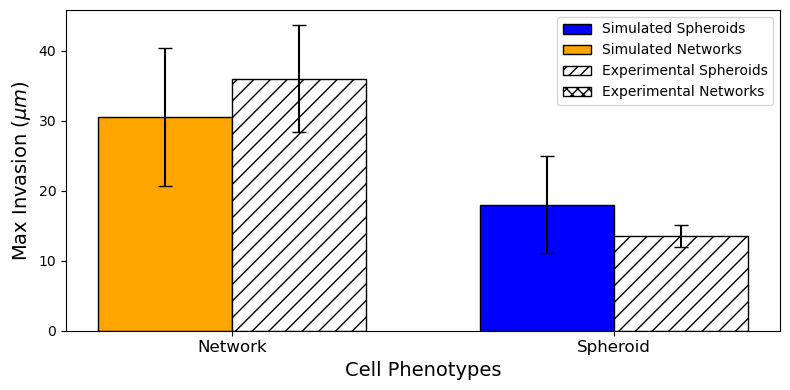

In [14]:
# Function to read and process data from a given folder
def read_and_process_cell_invasion(folder_path):
    data_list = []

    # Loop through each CSV file and read the data
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        data = pd.read_csv(file_path)
        data_list.append(data)

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Convert mcs to hours (1000 mcs = 24 hours, so 1 mcs = 0.024 hours)
    all_data['hours'] = all_data['mcs'] * 0.024

    # Multiply cell_invasion by 2
    all_data['cell_invasion'] *= 2

    # Calculate the mean and standard deviation for cell_invasion at each hour
    std_data = all_data.groupby('hours')['cell_invasion'].agg(
        mean=np.mean,
        std=np.std
    ).reset_index()

    return std_data

# Read and process data from both folders
#std_data_ec = read_and_process_cell_invasion('network_1000_10_005')
#std_data_sp = read_and_process_cell_invasion('spheroid_1000_10_0005')

#std_data_ec = read_and_process_cell_invasion('network_500_25_0001')
#std_data_sp = read_and_process_cell_invasion('spheroid_1000_15_0001')

#std_data_ec = read_and_process_cell_invasion('network_500_25_005')
#std_data_sp = read_and_process_cell_invasion('spheroid_500_10_0005')


std_data_ec = read_and_process_cell_invasion('network_335_39_0025')
std_data_sp = read_and_process_cell_invasion('spheroid_688_10_00001')


# Experimental data
labels = ['Network', 'Spheroid']
experiment_means = [36.03, 13.58]
experiment_errors = [7.63, 1.56]  # Experimental errors for the bars

# Filter data for 60 hours
data_at_60_hours_ec = std_data_ec[std_data_ec['hours'] == 60]
data_at_60_hours_sp = std_data_sp[std_data_sp['hours'] == 60]

# Prepare data for plotting
def prepare_bar_data(data_ec, data_sp):
    mean_ec = data_ec['mean'].values[0] if not data_ec.empty else 0
    std_ec = data_ec['std'].values[0] if not data_ec.empty else 0
    mean_sp = data_sp['mean'].values[0] if not data_sp.empty else 0
    std_sp = data_sp['std'].values[0] if not data_sp.empty else 0
    return [mean_ec, mean_sp], [std_ec, std_sp]

# Create bar plot for data at 60 hours
fig, ax = plt.subplots(figsize=(8, 4))

simulated_means_60, simulated_stds_60 = prepare_bar_data(data_at_60_hours_ec, data_at_60_hours_sp)

bar_width = 0.35
index = np.arange(len(labels))

# Bar plot for simulated data in blue (Spheroid) and orange (Network)
bars_simulated = ax.bar(index - bar_width / 2, simulated_means_60, bar_width, 
                        yerr=simulated_stds_60, capsize=5, label='Simulated Data', 
                        color=['orange', 'blue'], edgecolor='black')

# Bar plot for experimental data in white with hatching
bars_experimental = ax.bar(index + bar_width / 2, experiment_means, bar_width, 
                           yerr=experiment_errors, capsize=5, label='Experimental Data', 
                           color='white', edgecolor='black', hatch='//')

# Set labels, title, and legend
ax.set_xlabel('Cell Phenotypes', fontsize=14)
ax.set_ylabel('Max Invasion ($\mu m$)', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(labels, fontsize=12)

# Custom legend for clarity
legend_labels = [
    'Simulated Spheroids',
    'Simulated Networks',
    'Experimental Spheroids',
    'Experimental Networks'
]

# legend_handles = [
#     plt.Line2D([0], [0], color='blue', lw=4),
#     plt.Line2D([0], [0], color='orange', lw=4),
#     Patch(facecolor='white', edgecolor='black', hatch='//')
# ]

# Custom legend for clarity
legend_handles = [
    Patch(facecolor='blue', edgecolor='black', label='Simulated Spheroids'),
    Patch(facecolor='orange', edgecolor='black', label='Simulated Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Experimental Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='xxx', label='Experimental Spheroids')
]


ax.legend(legend_handles, legend_labels, fontsize=10)

# Improve the layout
plt.tight_layout()

# Save the plot
plt.savefig('hatching_barplot_cell_invasion_comparison_60_hours.png', dpi=1000, bbox_inches='tight')

# Display the plot
plt.show()

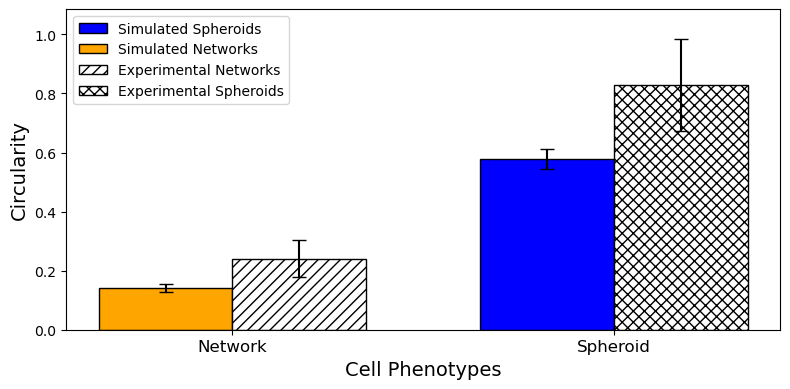

In [15]:
# Function to read and process circularity data from a given folder
def read_and_process_circularity(folder_path):
    data_list = []

    # Loop through each CSV file and read the data
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        try:
            data = pd.read_csv(file_path)
            data_list.append(data)
        except FileNotFoundError:
            print(f'File {file_path} not found. Skipping.')

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Calculate the maximum circularity for each MCS across all replicas
    summary_data = all_data.groupby('mcs')['circularity'].mean().reset_index()
    
    # Calculate the standard error for each MCS
    summary_se = all_data.groupby('mcs')['circularity'].sem().reset_index()
    
    return summary_data, summary_se

# Read and process circularity data from both folders
#summary_data_ec, summary_se_ec = read_and_process_circularity('network_1000_10_005')
#summary_data_sp, summary_se_sp = read_and_process_circularity('spheroid_1000_10_0005')

summary_data_ec, summary_se_ec = read_and_process_circularity('network_500_25_005')
summary_data_sp, summary_se_sp = read_and_process_circularity('spheroid_500_10_0005')

#summary_data_ec, summary_se_ec = read_and_process_circularity('network_335_39_0025')
#summary_data_sp, summary_se_sp = read_and_process_circularity('spheroid_688_10_00001')

# Define the end MCS for day 7 (7000 MCS)
end_mcs_ec = 7000
end_mcs_sp = 7000

# Get the maximum circularity and its standard error at day 7
end_circularity_ec = summary_data_ec[summary_data_ec['mcs'] == end_mcs_ec]['circularity'].values[0]
end_circularity_sp = summary_data_sp[summary_data_sp['mcs'] == end_mcs_sp]['circularity'].values[0]

se_circularity_ec = summary_se_ec[summary_se_ec['mcs'] == end_mcs_ec]['circularity'].values[0]
se_circularity_sp = summary_se_sp[summary_se_sp['mcs'] == end_mcs_sp]['circularity'].values[0]

# Experimental data and their standard errors
experiment_circularity = [0.24, 0.83]
experiment_errors = [0.063, 0.156]

# Prepare data for plotting
labels = ['Network', 'Spheroid']
circularity_simulation = [end_circularity_ec, end_circularity_sp]
se_simulation = [se_circularity_ec, se_circularity_sp]

# Create bar plot for circularity
fig, ax = plt.subplots(figsize=(8, 4))

bar_width = 0.35
index = np.arange(len(labels))

# Bar plot for simulation data in blue and orange with black edges
bars_simulation = ax.bar(index - bar_width/2, circularity_simulation, bar_width, label='Simulation', 
                         color=['orange', 'blue'], edgecolor='black', yerr=se_simulation, capsize=5)

# Bar plot for experimental data in white with black edges
bars_experiment = ax.bar(index + bar_width/2, experiment_circularity, bar_width, label='Experiment', 
                         color='white', edgecolor='black', yerr=experiment_errors, capsize=5)

# Add vertical hatch patterns to distinguish experimental data
for bar, hatch in zip(bars_experiment, ['///', 'xxx']):
    bar.set_hatch(hatch)

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Cell Phenotypes', fontsize=14)
ax.set_ylabel('Circularity', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, max(max(circularity_simulation) + max(se_simulation), max(experiment_circularity) + max(experiment_errors)) + 0.1)  # Dynamic y-axis limit

# Custom legend for clarity
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Simulated Spheroids'),
    Patch(facecolor='orange', edgecolor='black', label='Simulated Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Experimental Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='xxx', label='Experimental Spheroids')
]

ax.legend(handles=legend_elements, fontsize=10)

# Save plot
plt.tight_layout()
plt.savefig('hatch_patterns_circularity_comparison.png', dpi=2000, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


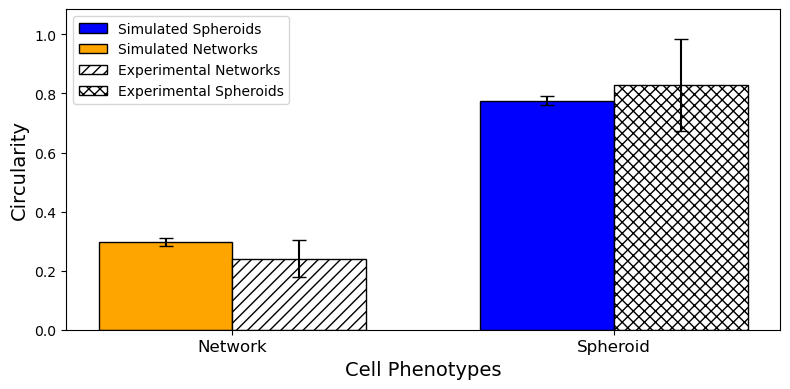

In [16]:
# Function to read and process circularity data from a given folder
def read_and_process_circularity(folder_path):
    data_list = []

    # Loop through each CSV file and read the data
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        try:
            data = pd.read_csv(file_path)
            data_list.append(data)
        except FileNotFoundError:
            print(f'File {file_path} not found. Skipping.')

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Calculate the maximum circularity for each MCS across all replicas
    summary_data = all_data.groupby('mcs')['circularity'].mean().reset_index()
    
    # Calculate the standard error for each MCS
    summary_se = all_data.groupby('mcs')['circularity'].sem().reset_index()
    
    return summary_data, summary_se

# Read and process circularity data from both folders
#summary_data_ec, summary_se_ec = read_and_process_circularity('network_1')
#summary_data_sp, summary_se_sp = read_and_process_circularity('spheroid_1')


#summary_data_ec, summary_se_ec = read_and_process_circularity('network_500_25_005')
#summary_data_sp, summary_se_sp = read_and_process_circularity('spheroid_500_10_0005')

summary_data_ec, summary_se_ec = read_and_process_circularity('network_335_39_0025')
summary_data_sp, summary_se_sp = read_and_process_circularity('spheroid_688_10_00001')

# Define the end MCS for day 7 (7000 MCS)
end_mcs_ec = 7000
end_mcs_sp = 7000

# Get the maximum circularity and its standard error at day 7
end_circularity_ec = summary_data_ec[summary_data_ec['mcs'] == end_mcs_ec]['circularity'].values[0]
end_circularity_sp = summary_data_sp[summary_data_sp['mcs'] == end_mcs_sp]['circularity'].values[0]

se_circularity_ec = summary_se_ec[summary_se_ec['mcs'] == end_mcs_ec]['circularity'].values[0]
se_circularity_sp = summary_se_sp[summary_se_sp['mcs'] == end_mcs_sp]['circularity'].values[0]

# Experimental data and their standard errors
experiment_circularity = [0.24, 0.83]
experiment_errors = [0.063, 0.156]

# Prepare data for plotting
labels = ['Network', 'Spheroid']
circularity_simulation = [end_circularity_ec, end_circularity_sp]
se_simulation = [se_circularity_ec, se_circularity_sp]

# Create bar plot for circularity
fig, ax = plt.subplots(figsize=(8, 4))

bar_width = 0.35
index = np.arange(len(labels))

# Bar plot for simulation data in blue and orange with black edges
bars_simulation = ax.bar(index - bar_width/2, circularity_simulation, bar_width, label='Simulation', 
                         color=['orange', 'blue'], edgecolor='black', yerr=se_simulation, capsize=5)

# Bar plot for experimental data in white with black edges
bars_experiment = ax.bar(index + bar_width/2, experiment_circularity, bar_width, label='Experiment', 
                         color='white', edgecolor='black', yerr=experiment_errors, capsize=5)

# Add vertical hatch patterns to distinguish experimental data
for bar, hatch in zip(bars_experiment, ['///', 'xxx']):
    bar.set_hatch(hatch)

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Cell Phenotypes', fontsize=14)
ax.set_ylabel('Circularity', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, max(max(circularity_simulation) + max(se_simulation), max(experiment_circularity) + max(experiment_errors)) + 0.1)  # Dynamic y-axis limit

# Custom legend for clarity
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Simulated Spheroids'),
    Patch(facecolor='orange', edgecolor='black', label='Simulated Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Experimental Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='xxx', label='Experimental Spheroids')
]

ax.legend(handles=legend_elements, fontsize=10)

# Save plot
plt.tight_layout()
plt.savefig('hatch_patterns_circularity_comparison.eps', dpi=2000, bbox_inches='tight')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


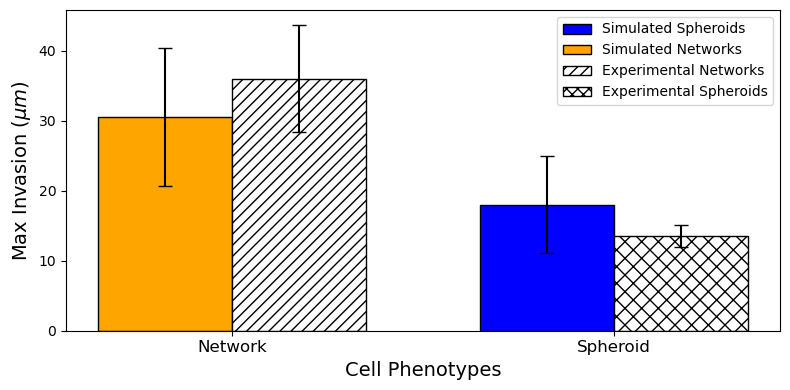

In [17]:
# Function to read and process cell invasion data from a given folder
def read_and_process_cell_invasion(folder_path):
    data_list = []

    # Loop through each CSV file and read the data
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        try:
            data = pd.read_csv(file_path)
            data_list.append(data)
        except FileNotFoundError:
            print(f'File {file_path} not found. Skipping.')

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Convert mcs to hours (1000 mcs = 24 hours, so 1 mcs = 0.024 hours)
    all_data['hours'] = all_data['mcs'] * 0.024

    # Multiply cell_invasion by 2
    all_data['cell_invasion'] *= 2

    # Calculate the mean and standard deviation for cell_invasion at each hour
    std_data = all_data.groupby('hours')['cell_invasion'].agg(
        mean=np.mean,
        std=np.std
    ).reset_index()

    return std_data

# Read and process data from both folders
#std_data_ec = read_and_process_cell_invasion('network_1000_10_005')
#std_data_sp = read_and_process_cell_invasion('spheroid_1000_10_0005')


#std_data_ec = read_and_process_cell_invasion('network_500_25_005')
#std_data_sp = read_and_process_cell_invasion('spheroid_500_10_0005')


std_data_ec = read_and_process_cell_invasion('network_335_39_0025')
std_data_sp = read_and_process_cell_invasion('spheroid_688_10_00001')

# Experimental data
labels = ['Network', 'Spheroid']
experiment_means = [36.03, 13.58]
experiment_errors = [7.63, 1.56]  # Experimental errors for the bars

# Filter data for 60 hours
data_at_60_hours_ec = std_data_ec[std_data_ec['hours'] == 60]
data_at_60_hours_sp = std_data_sp[std_data_sp['hours'] == 60]

# Prepare data for plotting
def prepare_bar_data(data_ec, data_sp):
    mean_ec = data_ec['mean'].values[0] if not data_ec.empty else 0
    std_ec = data_ec['std'].values[0] if not data_ec.empty else 0
    mean_sp = data_sp['mean'].values[0] if not data_sp.empty else 0
    std_sp = data_sp['std'].values[0] if not data_sp.empty else 0
    return [mean_ec, mean_sp], [std_ec, std_sp]

# Create bar plot for data at 60 hours
fig, ax = plt.subplots(figsize=(8, 4))

simulated_means_60, simulated_stds_60 = prepare_bar_data(data_at_60_hours_ec, data_at_60_hours_sp)

bar_width = 0.35
index = np.arange(len(labels))

# Bar plot for simulated data in blue (Spheroid) and orange (Network)
bars_simulated = ax.bar(index - bar_width / 2, simulated_means_60, bar_width, 
                        yerr=simulated_stds_60, capsize=5, label='Simulated Data', 
                        color=['orange', 'blue'], edgecolor='black')

# Bar plot for experimental data in white with black edges
bars_experimental = ax.bar(index + bar_width / 2, experiment_means, bar_width, 
                           yerr=experiment_errors, capsize=5, label='Experimental Data', 
                           color='white', edgecolor='black')

# Add vertical hatch patterns to distinguish experimental data
for bar, hatch in zip(bars_experimental, ['///', 'xx']):
    bar.set_hatch(hatch)

# Add hatch patterns on top of bars (to bring them in front)
for bar, hatch in zip(bars_experimental, ['///', 'xx']):
    bar.set_hatch(hatch)
    bar.set_edgecolor('black')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Cell Phenotypes', fontsize=14)
ax.set_ylabel('Max Invasion ($\mu m$)', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(labels, fontsize=12)

# Custom legend for clarity
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='Simulated Spheroids'),
    Patch(facecolor='orange', edgecolor='black', label='Simulated Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Experimental Networks'),
    Patch(facecolor='white', edgecolor='black', hatch='xxx', label='Experimental Spheroids')
]

ax.legend(handles=legend_elements, fontsize=10)

# Improve the layout
plt.tight_layout()

# Save the plot
plt.savefig('hatch_patterns_cell_invasion_comparison_60_hours.eps', dpi=2000, bbox_inches='tight')

# Display the plot
plt.show()

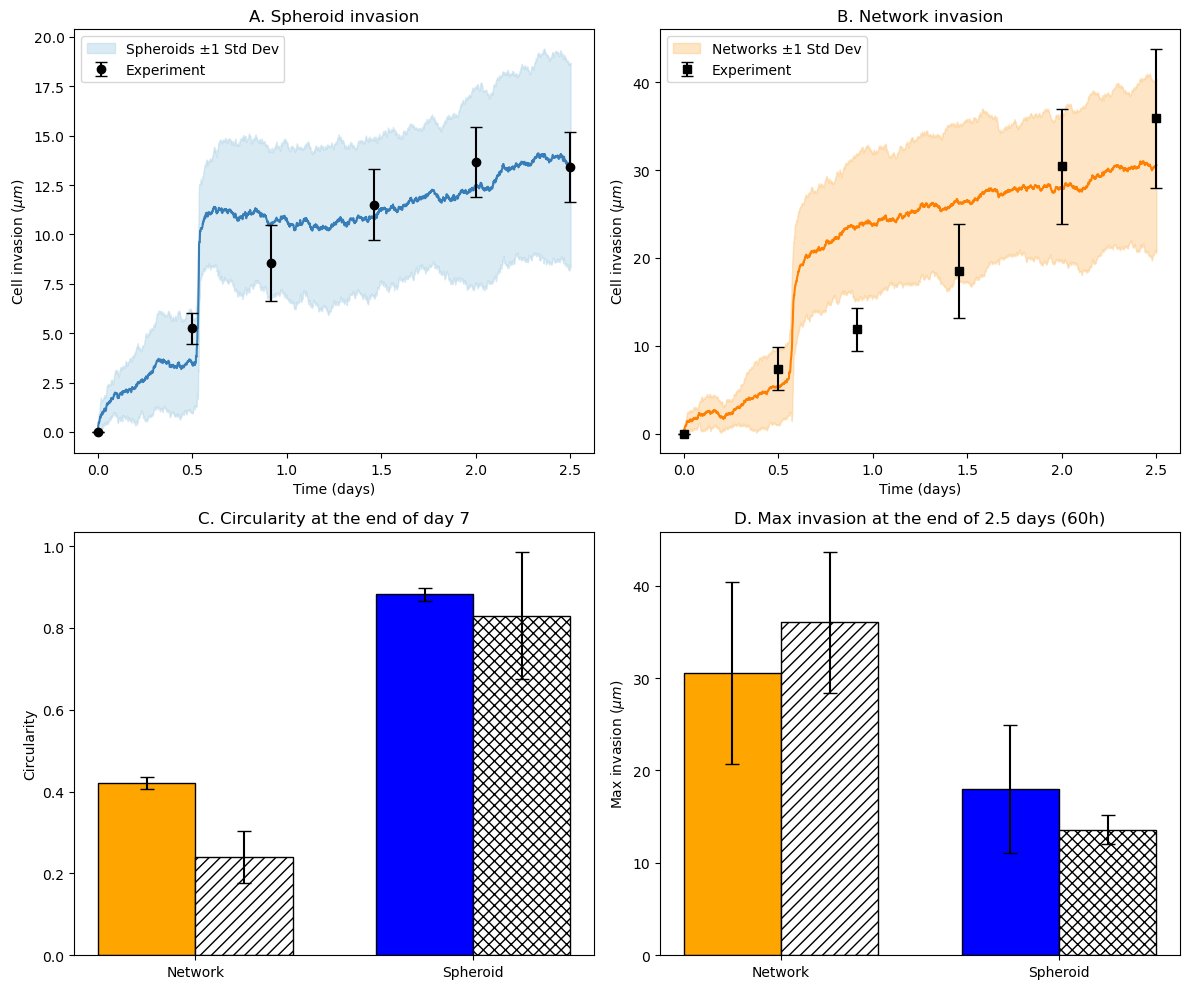

In [18]:
def read_and_process_data(folder_path):
    data_list = []
    if 'spheroid' in folder_path.lower():
        invasion_multiplier = 1.5
    elif 'network' in folder_path.lower():
        invasion_multiplier = 2
    else:
        raise ValueError("Folder name must contain 'spheroid' or 'network'.")

    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        data = pd.read_csv(file_path)
        data_list.append(data)

    all_data = pd.concat(data_list, ignore_index=True)
    all_data['hours'] = all_data['mcs'] / 1000
    all_data['cell_invasion'] *= invasion_multiplier
    filtered_data = all_data[all_data['hours'] <= 2.5]

    summary_data = filtered_data.groupby('hours').agg({
        'circularity': ['mean', 'std'],
        'cell_invasion': ['mean', 'std']
    }).reset_index()

    summary_data.columns = [
        'hours', 'circularity_mean', 'circularity_std',
        'cell_invasion_mean', 'cell_invasion_std'
    ]
    return summary_data

def read_and_process_circularity(folder_path):
    data_list = []
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        data = pd.read_csv(file_path)
        data_list.append(data)

    all_data = pd.concat(data_list, ignore_index=True)
    summary_data = all_data.groupby('mcs')['circularity'].max().reset_index()
    summary_se = all_data.groupby('mcs')['circularity'].sem().reset_index()
    return summary_data, summary_se

def read_and_process_cell_invasion(folder_path):
    data_list = []
    for i in range(1, 21):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        data = pd.read_csv(file_path)
        data_list.append(data)

    all_data = pd.concat(data_list, ignore_index=True)
    all_data['hours'] = all_data['mcs'] * 0.024
    all_data['cell_invasion'] *= 2

    std_data = all_data.groupby('hours')['cell_invasion'].agg(
        mean=np.mean, std=np.std
    ).reset_index()
    return std_data


# ==========================================================
# Read data
# ==========================================================
# summary_data_ec = read_and_process_data('network_500_25_0001')
# summary_data_sp = read_and_process_data('spheroid_1000_15_0001')
# circ_ec, circ_se_ec = read_and_process_circularity('network_500_25_0001')
# circ_sp, circ_se_sp = read_and_process_circularity('spheroid_1000_15_0001')
# inv_ec = read_and_process_cell_invasion('network_500_25_0001')
# inv_sp = read_and_process_cell_invasion('spheroid_1000_15_0001')

summary_data_ec = read_and_process_data('network_335_39_0025')
summary_data_sp = read_and_process_data('spheroid_688_10_00001')
circ_ec, circ_se_ec = read_and_process_circularity('network_335_39_0025')
circ_sp, circ_se_sp = read_and_process_circularity('spheroid_688_10_00001')
inv_ec = read_and_process_cell_invasion('network_335_39_0025')
inv_sp = read_and_process_cell_invasion('spheroid_688_10_00001')



# ==========================================================
# Experimental data
# ==========================================================
network_hours = np.array([0,12,22,35,48,60]) / 24
network_conc = [0, 7.41, 11.88, 18.53, 30.42, 35.91]
network_error = [0, 2.43, 2.43, 5.37, 6.52, 7.92]

spheroid_hours = np.array([0,12,22,35,48,60]) / 24
spheroid_conc = [0, 5.24, 8.56, 11.50, 13.67, 13.42]
spheroid_error = [0, 0.77, 1.92, 1.79, 1.79, 1.79]

experiment_circularity = [0.24, 0.83]
experiment_circ_err = [0.063, 0.156]

experiment_inv = [36.03, 13.58]
experiment_inv_err = [7.63, 1.56]

# ==========================================================
# Plotting in 2×2 with labels
# ==========================================================
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
letters = ['A', 'B', 'C', 'D']

# --- A: Spheroid invasion dynamics ---
ax[0,0].fill_between(summary_data_sp['hours'],
                     summary_data_sp['cell_invasion_mean'] - summary_data_sp['cell_invasion_std'],
                     summary_data_sp['cell_invasion_mean'] + summary_data_sp['cell_invasion_std'],
                     color='#a6cee3', alpha=0.4, label='Spheroids ±1 Std Dev')
ax[0,0].plot(summary_data_sp['hours'], summary_data_sp['cell_invasion_mean'], color='#377eb8')
ax[0,0].errorbar(spheroid_hours, spheroid_conc, yerr=spheroid_error, fmt='o', color='black',
                 capsize=4, label='Experiment')
ax[0,0].set_xlabel('Time (days)')
ax[0,0].set_ylabel('Cell invasion ($\mu m$)')
ax[0,0].legend()
ax[0,0].set_title('A. Spheroid invasion')

# --- B: Network invasion dynamics ---
ax[0,1].fill_between(summary_data_ec['hours'],
                     summary_data_ec['cell_invasion_mean'] - summary_data_ec['cell_invasion_std'],
                     summary_data_ec['cell_invasion_mean'] + summary_data_ec['cell_invasion_std'],
                     color='#fdbf6f', alpha=0.4, label='Networks ±1 Std Dev')
ax[0,1].plot(summary_data_ec['hours'], summary_data_ec['cell_invasion_mean'], color='#ff7f00')
ax[0,1].errorbar(network_hours, network_conc, yerr=network_error, fmt='s', color='black',
                 capsize=4, label='Experiment')
ax[0,1].set_xlabel('Time (days)')
ax[0,1].set_ylabel('Cell invasion ($\mu m$)')
ax[0,1].legend()
ax[0,1].set_title('B. Network invasion')

# --- C: Circularity comparison ---
labels = ['Network', 'Spheroid']
circ_sim = [circ_ec[circ_ec['mcs']==7000]['circularity'].values[0],
            circ_sp[circ_sp['mcs']==7000]['circularity'].values[0]]
circ_err = [circ_se_ec[circ_se_ec['mcs']==7000]['circularity'].values[0],
            circ_se_sp[circ_se_sp['mcs']==7000]['circularity'].values[0]]

x = np.arange(len(labels))
bar_width = 0.35
bars1 = ax[1,0].bar(x - bar_width/2, circ_sim, bar_width,
                    yerr=circ_err, capsize=5,
                    color=['orange','blue'], edgecolor='black', label='Simulation')
bars2 = ax[1,0].bar(x + bar_width/2, experiment_circularity, bar_width,
                    yerr=experiment_circ_err, capsize=5,
                    color='white', edgecolor='black', label='Experiment')
for bar,hatch in zip(bars2,['///','xxx']):
    bar.set_hatch(hatch)
ax[1,0].set_xticks(x)
ax[1,0].set_xticklabels(labels)
ax[1,0].set_ylabel('Circularity')
ax[1,0].set_title('C. Circularity at the end of day 7')

# --- D: Invasion at 60 hours ---
sim_means = [inv_ec[inv_ec['hours']==60]['mean'].values[0],
             inv_sp[inv_sp['hours']==60]['mean'].values[0]]
sim_stds  = [inv_ec[inv_ec['hours']==60]['std'].values[0],
             inv_sp[inv_sp['hours']==60]['std'].values[0]]

bars3 = ax[1,1].bar(x - bar_width/2, sim_means, bar_width,
                    yerr=sim_stds, capsize=5,
                    color=['orange','blue'], edgecolor='black', label='Simulation')
bars4 = ax[1,1].bar(x + bar_width/2, experiment_inv, bar_width,
                    yerr=experiment_inv_err, capsize=5,
                    color='white', edgecolor='black', label='Experiment')
for bar,hatch in zip(bars4,['///','xxx']):
    bar.set_hatch(hatch)
ax[1,1].set_xticks(x)
ax[1,1].set_xticklabels(labels)
ax[1,1].set_ylabel('Max invasion ($\mu m$)')
ax[1,1].set_title('D. Max invasion at the end of 2.5 days (60h)')

# --- Global figure settings ---
plt.tight_layout()
plt.savefig('combined_2x2_plots.png', dpi=500, bbox_inches='tight')
plt.show()


### Testing

In [19]:
def parse_folder_metadata(folder_name):
    """
    Parse folder names like:
        'network_500_25_005'
        'spheroid_500_10_0005'
        'spheriod_500_10_0005'  (typo-tolerant)

    Returns
    -------
    phenotype : str       ('network' or 'spheroid')
    lam : float           (e.g., 500.0)
    jcc : float           (e.g., 25.0)
    k : float             (e.g., 0.05 or 0.005)
    """
    base = os.path.basename(folder_name)
    parts = base.split('_')
    if len(parts) < 4:
        raise ValueError(
            f"Folder name '{base}' does not match expected format "
            "'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'."
        )

    ph_raw = parts[0].lower()
    if ph_raw.startswith('net'):
        phenotype = 'network'
    elif ph_raw.startswith('sph'):
        # accept both 'spheroid' and 'spheriod'
        phenotype = 'spheroid'
    else:
        raise ValueError(
            f"Could not determine phenotype from folder name '{base}'. "
            "Expected something starting with 'network' or 'spheroid/spheriod'."
        )

    lam = float(parts[1])
    jcc = float(parts[2])
    k_str = parts[3]

    # Handle k; support both decimal and zero-padded formats
    if '.' in k_str:
        k = float(k_str)
    else:
        # Use length-based scaling for formats like '005' -> 0.05, '0005' -> 0.005
        if len(k_str) == 3:
            k = float(k_str) / 100.0   # 005 -> 5/100 = 0.05
        elif len(k_str) == 4:
            k = float(k_str) / 1000.0  # 0005 -> 5/1000 = 0.005
        else:
            # Fall back to just casting; you can tweak this if you have other patterns
            k = float(k_str)

    return phenotype, lam, jcc, k

In [20]:
def read_and_process_data(folder_path, n_files=20):
    """
    Reads celldata1.csv ... celldata{n_files}.csv from a folder named like:
        'network_500_25_005' or 'spheroid_500_10_0005'

    Computes mean/std for circularity and cell_invasion vs time (days),
    and attaches phenotype + parameter metadata from the folder name.
    """
    data_list = []

    # Parse phenotype and parameters from folder name
    phenotype, lam, jcc, k = parse_folder_metadata(folder_path)

    # Choose invasion multiplier based on phenotype
    # (same multiplier for both here, update if you need different ones)
    invasion_multiplier = 2.0

    # Read CSVs celldata1.csv to celldata{n_files}.csv
    for i in range(1, n_files + 1):
        file_path = os.path.join(folder_path, f'celldata{i}.csv')
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Missing expected file: {file_path}")
        data = pd.read_csv(file_path)
        data_list.append(data)

    # Concatenate all data into a single DataFrame
    all_data = pd.concat(data_list, ignore_index=True)

    # Convert MCS to days (1000 MCS = 1 day)
    all_data['hours'] = all_data['mcs'] / 1000.0

    # Apply appropriate cell_invasion multiplier
    all_data['cell_invasion'] *= invasion_multiplier

    # Filter data to include only up to 2.5 days (~60 hours)
    filtered_data = all_data[all_data['hours'] <= 2.5]

    # Calculate mean and standard deviation
    summary_data = (
        filtered_data
        .groupby('hours')
        .agg({
            'circularity': ['mean', 'std'],
            'cell_invasion': ['mean', 'std']
        })
        .reset_index()
    )

    # Flatten column names
    summary_data.columns = [
        'hours',
        'circularity_mean', 'circularity_std',
        'cell_invasion_mean', 'cell_invasion_std'
    ]

    # Add metadata columns from folder name
    summary_data['phenotype'] = phenotype      # 'network' or 'spheroid'
    summary_data['lambda'] = lam
    summary_data['jcc'] = jcc
    summary_data['k'] = k

    return summary_data

In [21]:
def read_many_folders(parent_dir, folder_names=None, n_files=20):
    """
    Reads and processes multiple folders under parent_dir.

    Folder names should look like: 'network_500_25_005', 'spheroid_500_10_0005', etc.
    """
    if folder_names is None:
        folder_names = [
            d for d in os.listdir(parent_dir)
            if os.path.isdir(os.path.join(parent_dir, d))
        ]

    summaries = {}
    for name in folder_names:
        folder_path = os.path.join(parent_dir, name)
        try:
            summaries[name] = read_and_process_data(folder_path, n_files=n_files)
        except Exception as e:
            print(f"Skipping folder '{name}' due to error: {e}")
            continue

    return summaries

In [23]:
def plot_summaries_grid(
    summaries,
    nrows=4,
    ncols=8,
    metric='cell_invasion',  # or 'circularity'
    sharex=True,
    sharey=True,
    figsize=(24, 12)
):
    labels = list(summaries.keys())
    n_plots = len(labels)
    max_plots = nrows * ncols

    if n_plots > max_plots:
        print(
            f"Warning: {n_plots} folders but grid holds only {max_plots}. "
            f"Only plotting the first {max_plots}."
        )
        labels = labels[:max_plots]
        n_plots = max_plots

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        figsize=figsize
    )
    axes = axes.reshape(nrows, ncols)

    for idx, label in enumerate(labels):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        df = summaries[label]
        x = df['hours']

        if metric == 'cell_invasion':
            y_mean = df['cell_invasion_mean']
            y_std  = df['cell_invasion_std']
            ylabel = 'Cell invasion'
        elif metric == 'circularity':
            y_mean = df['circularity_mean']
            y_std  = df['circularity_std']
            ylabel = 'Circularity'
        else:
            raise ValueError("metric must be 'cell_invasion' or 'circularity'")

        ax.plot(x, y_mean, marker='o', linestyle='-')
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

        ax.set_title(label, fontsize=9)
        if r == nrows - 1:
            ax.set_xlabel('Time (days)', fontsize=8)
        if c == 0:
            ax.set_ylabel(ylabel, fontsize=8)

    for idx in range(n_plots, max_plots):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    plt.tight_layout()
    return fig, axes

In [26]:
parent_dir = r"C:\Users\tbenson2\Desktop\simulations"

summaries = read_many_folders(parent_dir, n_files=20)

# # 4 x 8 grid
# fig, axes = plot_summaries_grid(
#     summaries,
#     nrows=5,
#     ncols=8,
#     metric='cell_invasion',  # or 'circularity'
#     figsize=(24, 12)
# )
# plt.show()

Skipping folder '.ipynb_checkpoints' due to error: Folder name '.ipynb_checkpoints' does not match expected format 'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'.
Skipping folder 'Bayesian_Optimization_data' due to error: Folder name 'Bayesian_Optimization_data' does not match expected format 'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'.
Skipping folder 'BO_Aneesh_Khansa' due to error: Folder name 'BO_Aneesh_Khansa' does not match expected format 'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'.
Skipping folder 'BO_latinHypercube' due to error: Folder name 'BO_latinHypercube' does not match expected format 'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'.
Skipping folder 'ecc_data' due to error: Folder name 'ecc_data' does not match expected format 'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'.
Skipping folder 'ecc_data1' due to error: Folder name 'ecc_data1' does not match expected format 'phenotype_lambda_jcc_k', e.g. 'network_500_25_005'.
Skipping folder 'ec_

##### summaries

In [27]:
def plot_phenotype_vs_exp_grid(
    summaries,
    exp_df,
    phenotype='network',        # 'network' or 'spheroid'
    metric='cell_invasion',     # or 'circularity'
    nrows=4,
    ncols=8,
    sharex=True,
    sharey=True,
    figsize=(28, 14)
):
    """
    For each (lambda, jcc, k) combo, plot ONE phenotype (network OR spheroid)
    against its corresponding experimental data.
    """

    phenotype = str(phenotype).strip().lower()
    if phenotype not in ('network', 'spheroid'):
        raise ValueError("phenotype must be 'network' or 'spheroid'")

    # ----- Prep experimental data -----
    exp_df = exp_df.copy()
    exp_df['days'] = exp_df['Hours'] / 24.0   # convert hours -> days

    cond_lower = exp_df['Condition'].str.lower()

    if phenotype == 'network':
        exp_ph = exp_df[cond_lower.str.startswith('net')]
        sim_color = 'tab:orange'
        exp_marker = 's'  # square
    else:  # spheroid
        exp_ph = exp_df[cond_lower.str.startswith('sph')]
        sim_color = 'tab:blue'
        exp_marker = '^'  # triangle

    if metric == 'cell_invasion':
        exp_y_col = 'Invasion'
        ylabel = 'Cell invasion'
        sim_mean_col = 'cell_invasion_mean'
        sim_std_col  = 'cell_invasion_std'
    elif metric == 'circularity':
        # if you later add experimental circularity, adapt exp_y_col
        exp_y_col = 'Invasion'  # placeholder; currently only invasion is given
        ylabel = 'Circularity'
        sim_mean_col = 'circularity_mean'
        sim_std_col  = 'circularity_std'
    else:
        raise ValueError("metric must be 'cell_invasion' or 'circularity'")

    # ----- Collect simulation records with metadata -----
    records = []
    for label, df in summaries.items():
        ph = str(df['phenotype'].iloc[0]).strip().lower()
        lam = df['lambda'].iloc[0]
        jcc = df['jcc'].iloc[0]
        k   = df['k'].iloc[0]
        records.append({
            'label': label,
            'df': df,
            'phenotype': ph,
            'lambda': lam,
            'jcc': jcc,
            'k': k
        })

    # Group by parameter combo: (lambda, jcc, k) -> {phenotype: df}
    combos = defaultdict(dict)
    for rec in records:
        combo = (rec['lambda'], rec['jcc'], rec['k'])
        combos[combo][rec['phenotype']] = rec['df']

    # Now keep only combos that have THIS phenotype
    combo_items = []
    for combo, df_ph in combos.items():
        if phenotype in df_ph:
            combo_items.append((combo, df_ph[phenotype]))

    if not combo_items:
        print(f"No parameter combinations found for phenotype='{phenotype}'.")
        return None, None

    n_panels = len(combo_items)
    max_panels = nrows * ncols
    if n_panels > max_panels:
        print(
            f"Warning: {n_panels} parameter combos but grid holds only {max_panels}. "
            f"Only plotting the first {max_panels}."
        )
        combo_items = combo_items[:max_panels]
        n_panels = max_panels

    print(f"Plotting {n_panels} panels for phenotype='{phenotype}'.")

    # ----- Create figure & axes -----
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        figsize=figsize,
        dpi=150
    )

    axes = axes.reshape(nrows, ncols)

    first_legend = True

    for idx, (combo, df) in enumerate(combo_items):
        lam, jcc, kval = combo
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        ax.grid(True, which='both', linestyle='--', alpha=0.3)

        # ---- Simulation curve for THIS phenotype ----
        x = df['hours']  # already in days
        y_mean = df[sim_mean_col]
        y_std  = df[sim_std_col]

        ax.plot(
            x,
            y_mean,
            marker='o',
            linestyle='-',
            linewidth=1.8,
            markersize=3,
            label=f"{phenotype} (sim)",
            color=sim_color
        )
        ax.fill_between(
            x,
            y_mean - y_std,
            y_mean + y_std,
            alpha=0.18,
            color=sim_color
        )

        # ---- Overlay experimental data for THIS phenotype ----
        if not exp_ph.empty:
            ax.errorbar(
                exp_ph['days'],
                exp_ph[exp_y_col],
                yerr=exp_ph['Error'],
                fmt=exp_marker,
                markersize=5,
                linestyle='None',
                ecolor=sim_color,
                elinewidth=1.2,
                capsize=3,
                label=f'{phenotype} (exp)'
            )

        # ---- Title, labels, ticks ----
        ax.set_title(
            f"{phenotype.capitalize()} | λ={lam:.0f}, jcc={jcc:.0f}, k={kval:.4f}",
            fontsize=9
        )

        if r == nrows - 1:
            ax.set_xlabel('Time (days)', fontsize=8)
        if c == 0:
            ax.set_ylabel(ylabel, fontsize=8)

        ax.tick_params(axis='both', which='major', labelsize=7)

        if first_legend:
            ax.legend(fontsize=7, loc='upper left', framealpha=0.9)
            first_legend = False

    # Turn off unused axes
    for idx in range(n_panels, max_panels):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()   # <-- FORCE DISPLAY

    return fig, axes


def plot_network_vs_exp_grid(
    summaries,
    exp_df,
    metric='cell_invasion',
    nrows=5,
    ncols=8,
    sharex=True,
    sharey=True,
    figsize=(28, 14)
):
    return plot_phenotype_vs_exp_grid(
        summaries=summaries,
        exp_df=exp_df,
        phenotype='network',
        metric=metric,
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        figsize=figsize
    )


def plot_spheroid_vs_exp_grid(
    summaries,
    exp_df,
    metric='cell_invasion',
    nrows=5,
    ncols=8,
    sharex=True,
    sharey=True,
    figsize=(28, 14)
):
    return plot_phenotype_vs_exp_grid(
        summaries=summaries,
        exp_df=exp_df,
        phenotype='spheroid',
        metric=metric,
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        figsize=figsize
    )


Plotting 33 panels for phenotype='network'.


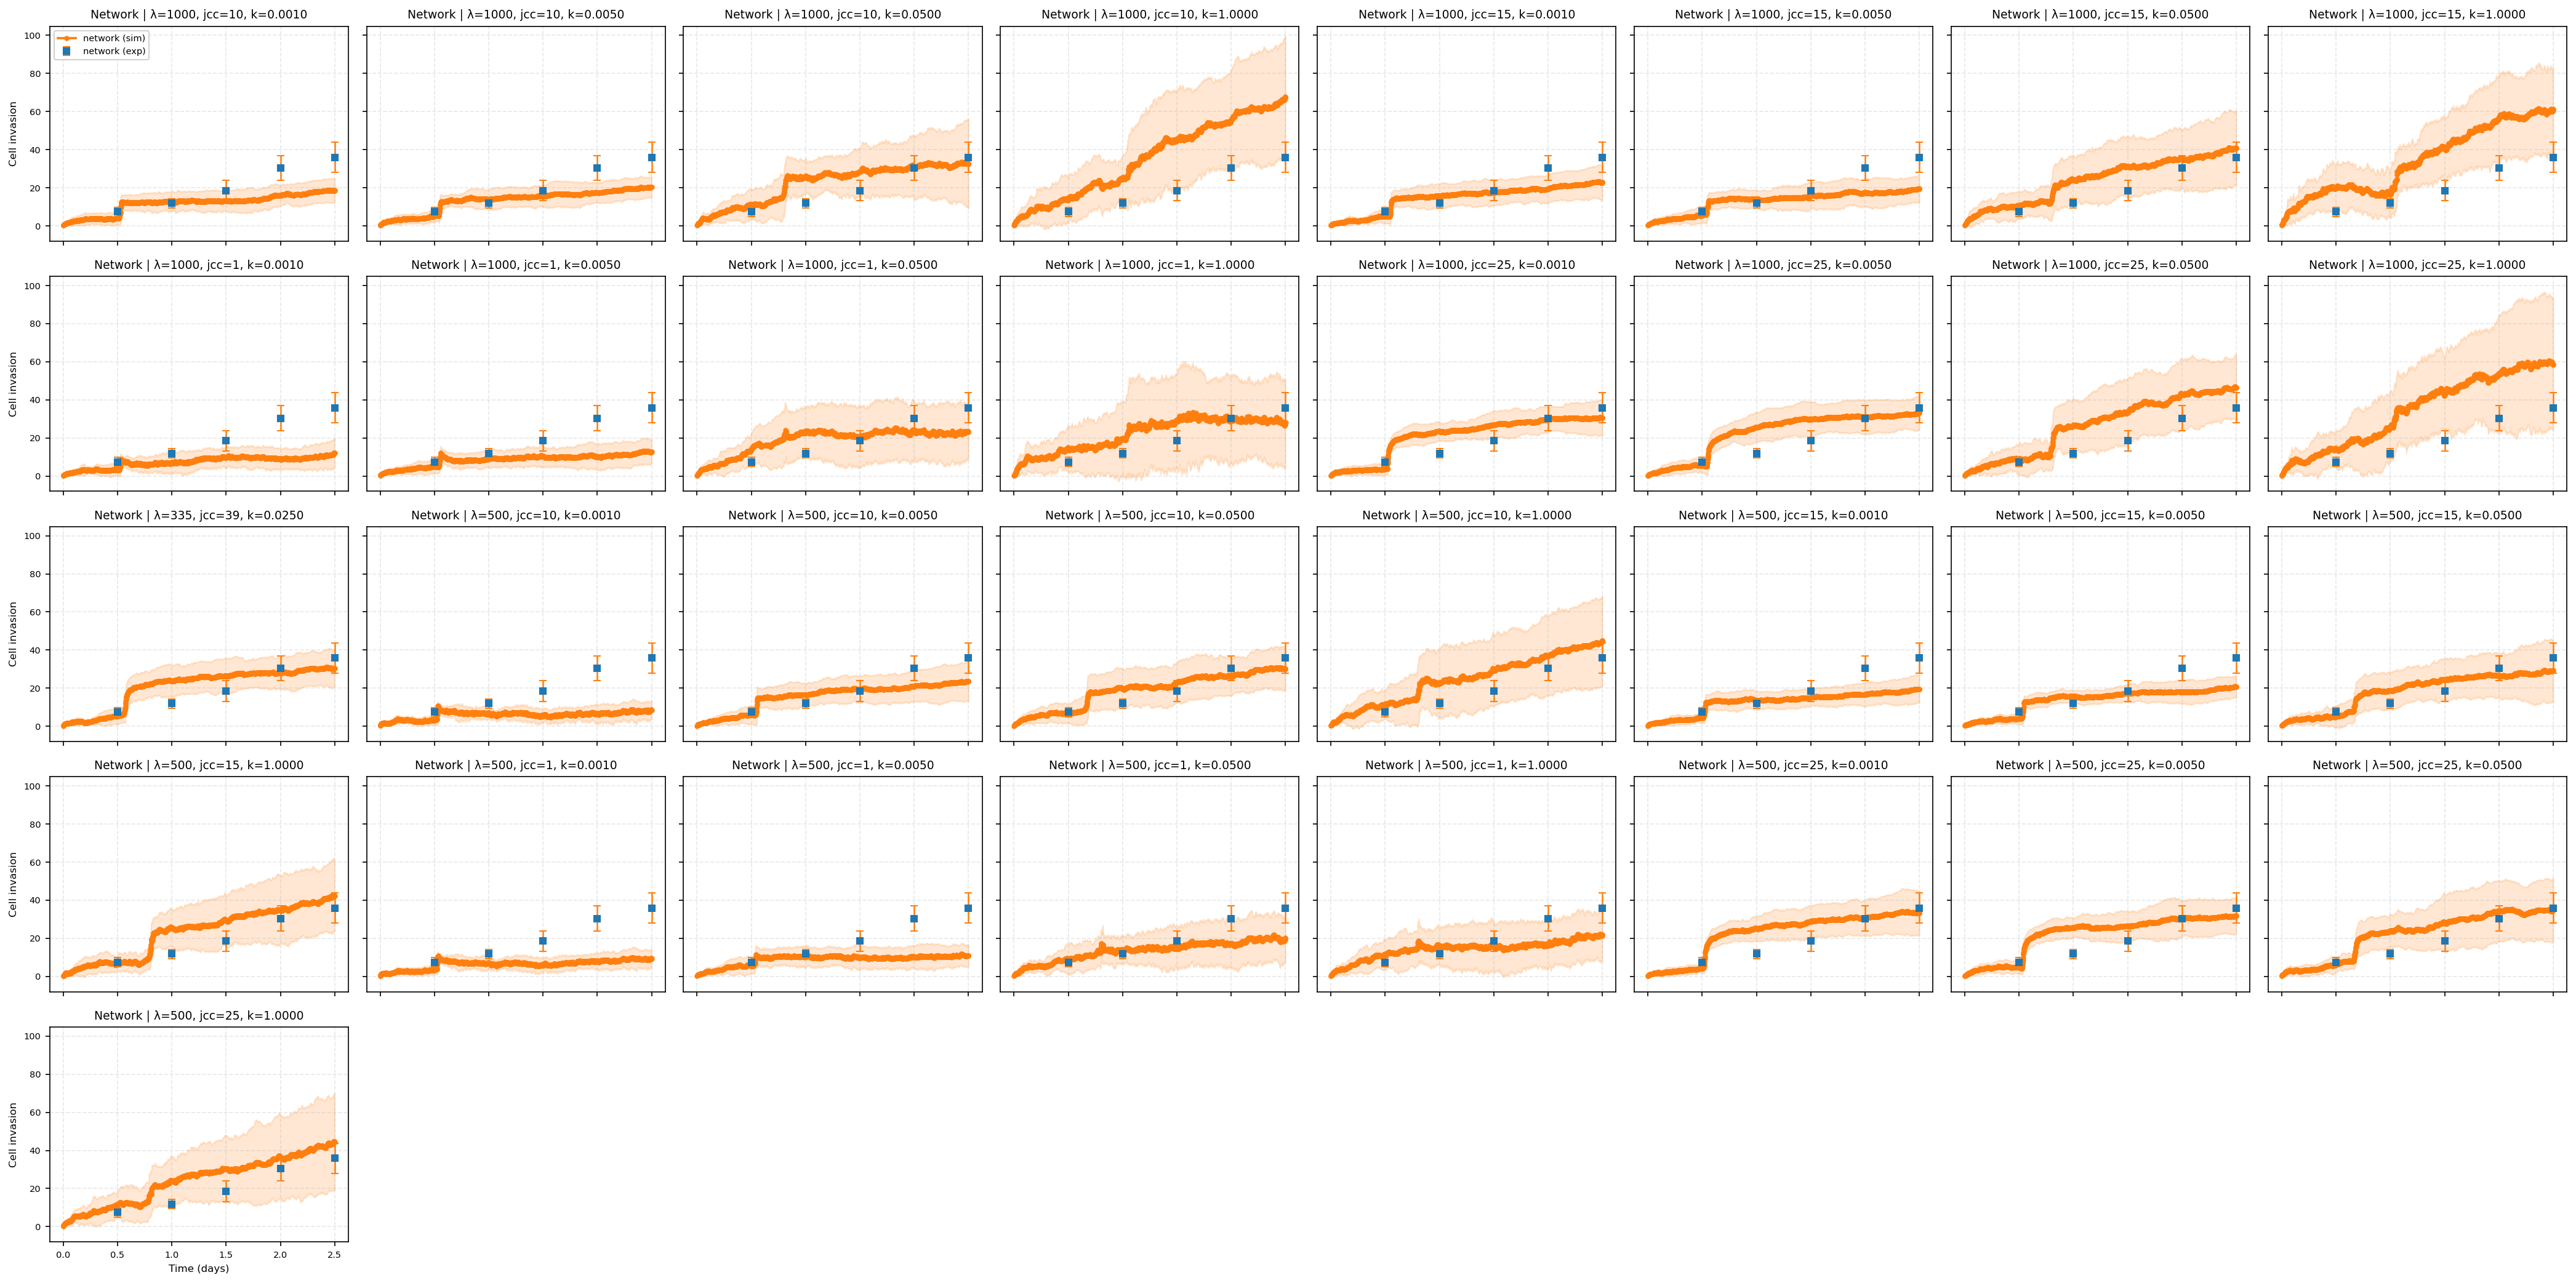

In [28]:
fig_net, axes_net = plot_network_vs_exp_grid(summaries, exp_data)

Plotting 33 panels for phenotype='spheroid'.


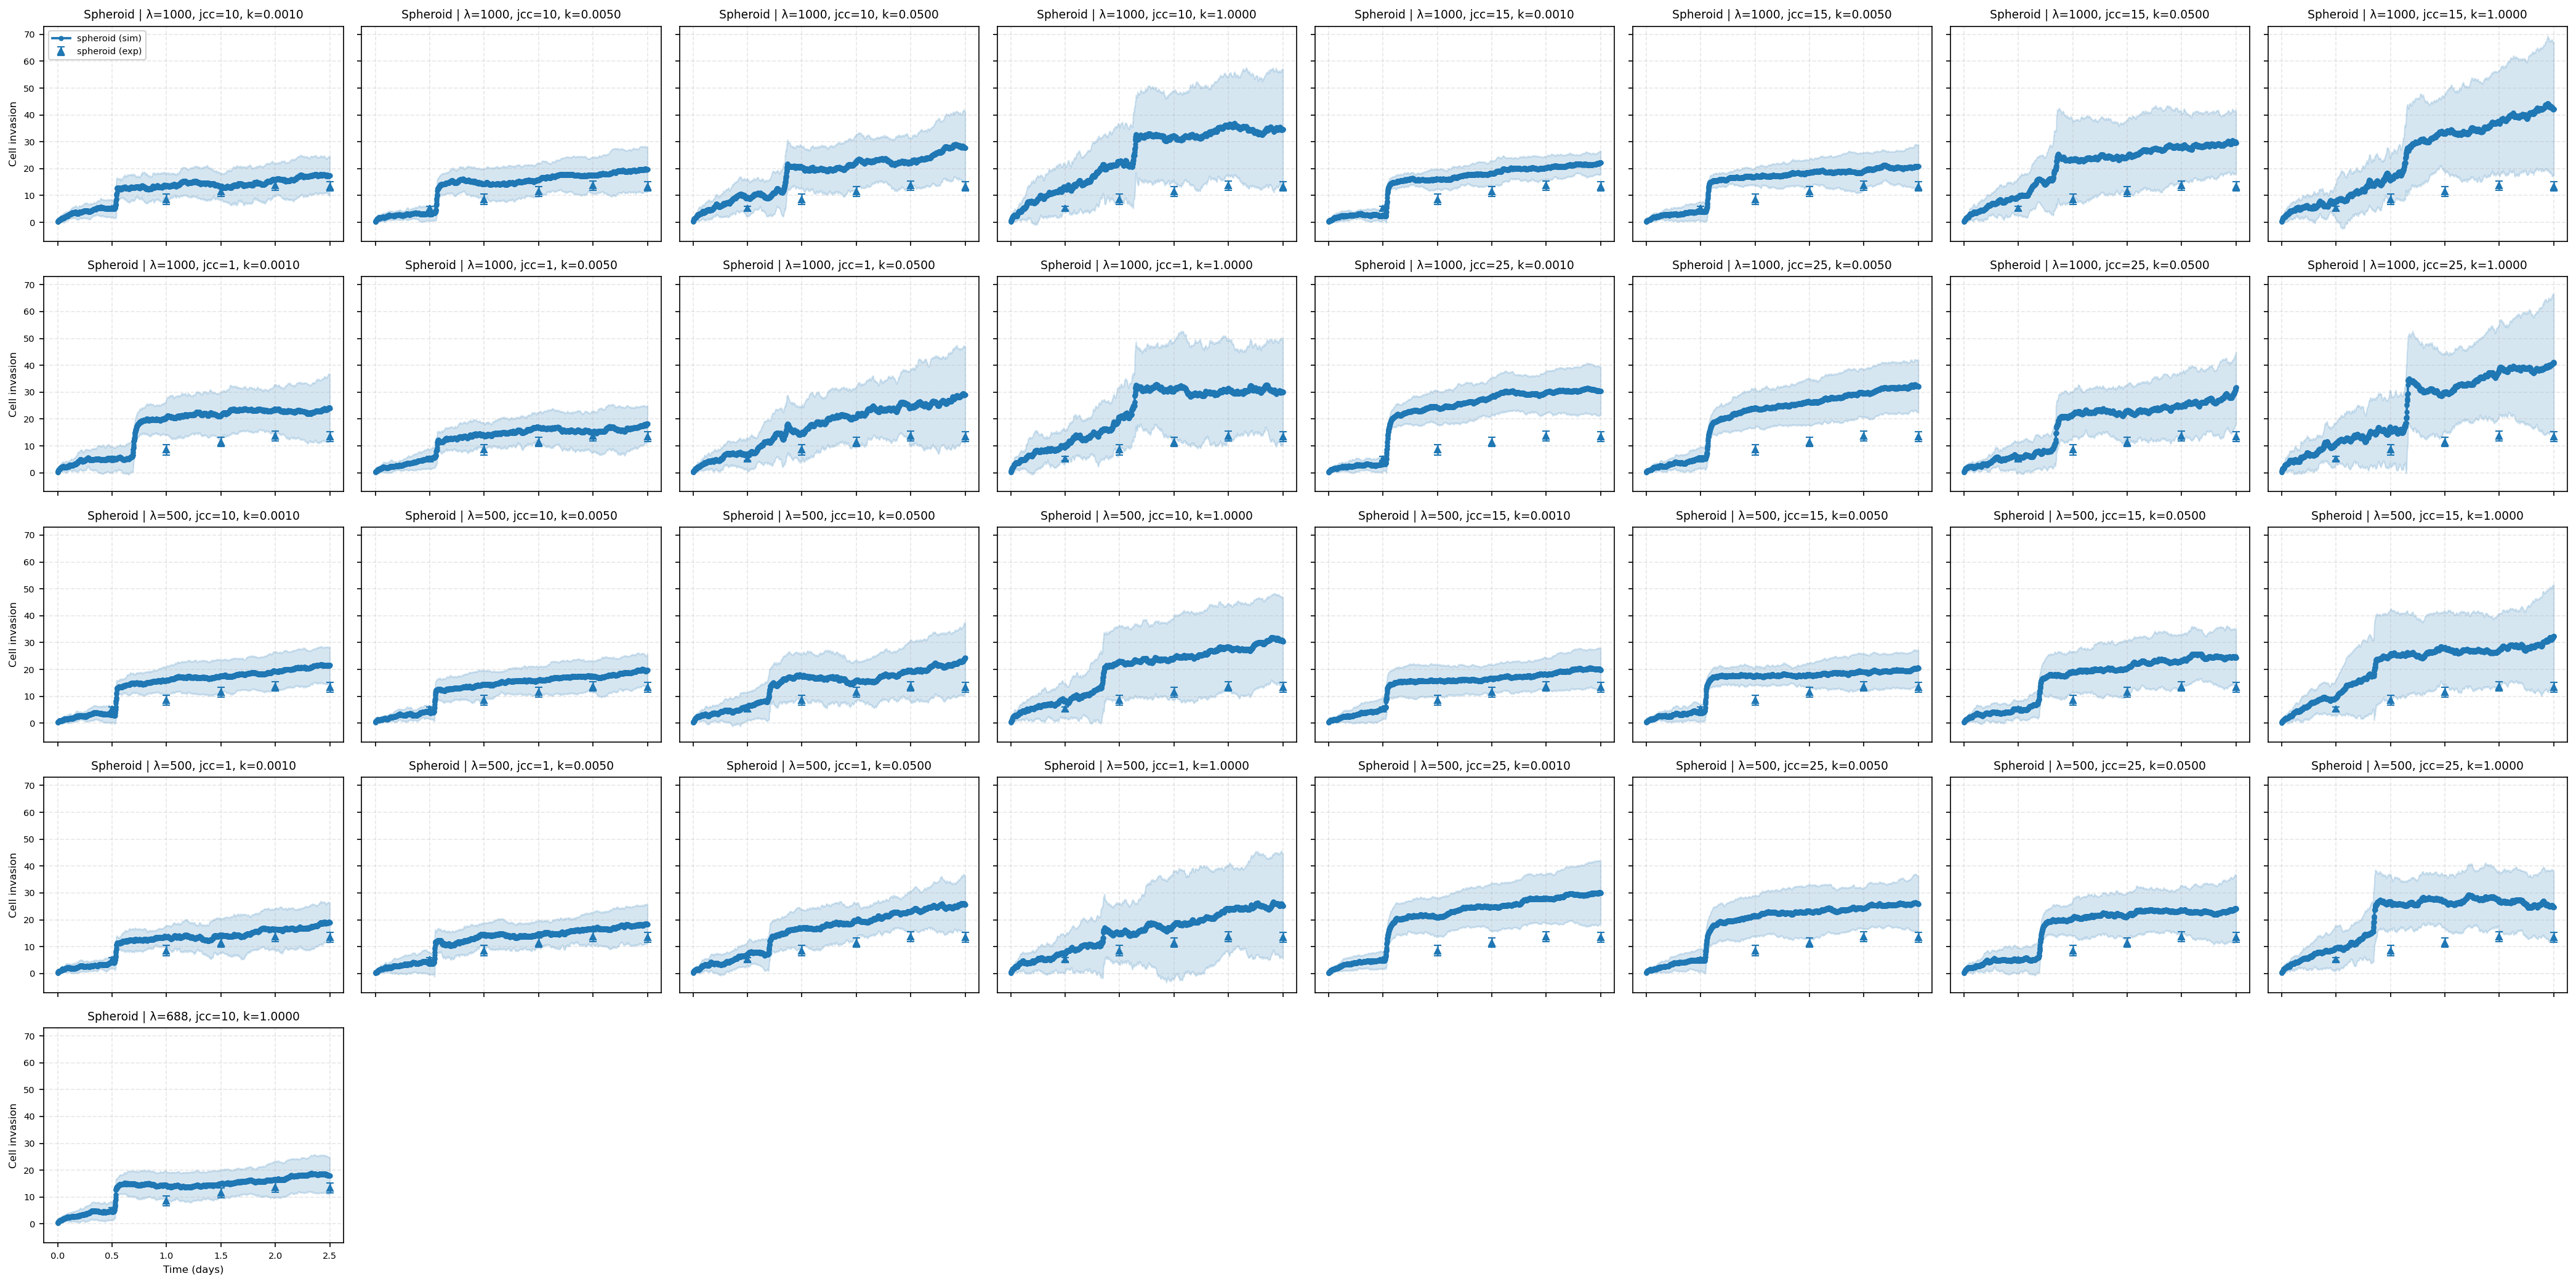

In [30]:
fig_sph, axes_sph = plot_spheroid_vs_exp_grid(summaries, exp_data)

#### Incorporate the four metrics:

In [31]:
def plot_summaries_grid_all_metrics(
    summaries,
    nrows=4,
    ncols=8,
    sharex=True,
    sharey=True,
    figsize=(24, 12),
    show_std=False,      # if True, show ±std bands for each metric
):
    """
    Plot all four metrics on the same axes for each folder:

        - dist_self_mean
        - dist_to_cell1_mean
        - max_pairwise_dist_mean
        - max_extent_mean
    """
    labels = list(summaries.keys())
    n_plots = len(labels)
    max_plots = nrows * ncols

    if n_plots == 0:
        print("No summaries to plot.")
        return None, None

    if n_plots > max_plots:
        print(
            f"Warning: {n_plots} folders but grid holds only {max_plots}. "
            f"Only plotting the first {max_plots}."
        )
        labels = labels[:max_plots]
        n_plots = max_plots

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        figsize=figsize
    )
    axes = axes.reshape(nrows, ncols)

    metric_cols = [
        ("dist_self_mean",         "dist_self_std",         "dist_self"),
        ("dist_to_cell1_mean",     "dist_to_cell1_std",     "dist_to_cell1"),
        ("max_pairwise_dist_mean", "max_pairwise_dist_std", "max_pairwise_dist"),
        ("max_extent_mean",        "max_extent_std",        "max_extent"),
    ]

    for idx, label in enumerate(labels):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        df = summaries[label]
        x = df['hours']

        for mean_col, std_col, mlabel in metric_cols:
            if mean_col not in df.columns:
                continue

            y_mean = df[mean_col]
            y_std = df.get(std_col, pd.Series(0, index=df.index)).fillna(0.0)

            ax.plot(x, y_mean, marker='o', linestyle='-', label=mlabel)

            if show_std:
                ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15)

        ax.set_title(label, fontsize=9)
        if r == nrows - 1:
            ax.set_xlabel('Time (hours)', fontsize=8)
        if c == 0:
            ax.set_ylabel('Distance (µm or pixelScaledDistance units)', fontsize=8)

        if idx == 0:
            ax.legend(fontsize=7)

    # Turn off unused subplots
    for idx in range(n_plots, max_plots):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()
    return fig, axes

In [32]:
def plot_summaries_grid_all_metrics_by_phenotype(
    summaries,
    phenotype='network',    # 'network' or 'spheroid'
    nrows=4,
    ncols=8,
    sharex=True,
    sharey=True,
    figsize=(24, 12)
):
    """
    Plot ALL four *raw* metrics (exact values) on the same axes for each folder,
    but only for a given phenotype ('network' or 'spheroid').

    Raw metrics expected in each summary DataFrame:
        - dist_self
        - dist_to_cell1
        - max_pairwise_dist
        - max_extent
    """
    ph_target = str(phenotype).strip().lower()

    # ---- Filter summaries by phenotype using the summary DataFrame itself ----
    filtered = {}
    for name, df in summaries.items():
        if 'phenotype' not in df.columns:
            print(f"Warning: 'phenotype' missing in summary for folder '{name}', skipping.")
            continue

        ph = str(df['phenotype'].iloc[0]).lower()
        if ph == ph_target:
            filtered[name] = df

    if not filtered:
        print(f"No summaries found for phenotype='{phenotype}'.")
        return None, None

    labels = list(filtered.keys())
    n_plots = len(labels)
    max_plots = nrows * ncols

    if n_plots > max_plots:
        print(
            f"Warning: {n_plots} folders but grid holds only {max_plots}. "
            f"Only plotting the first {max_plots}."
        )
        labels = labels[:max_plots]
        n_plots = max_plots

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        figsize=figsize
    )
    axes = axes.reshape(nrows, ncols)

    # Raw metric column names
    metric_cols = [
        ("dist_self",         "dist_self"),
        ("dist_to_cell1",     "dist_to_cell1"),
        ("max_pairwise_dist", "max_pairwise_dist"),
        ("max_extent",        "max_extent"),
    ]

    for idx, label in enumerate(labels):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        df = filtered[label]
        x = df['hours']

        # ---- Plot all four RAW metrics ----
        for col, mlabel in metric_cols:
            if col not in df.columns:
                continue

            y = df[col]
            ax.plot(x, y, marker='o', linestyle='-', label=mlabel)

        ax.set_title(label, fontsize=9)
        if r == nrows - 1:
            ax.set_xlabel('Time (hours)', fontsize=8)
        if c == 0:
            ax.set_ylabel('Distance (µm or scaled units)', fontsize=8)

        if idx == 0:
            ax.legend(fontsize=7, title=f"{phenotype} metrics")

    # Turn off unused subplots
    for idx in range(n_plots, max_plots):
        r = idx // ncols
        c = idx % ncols
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()
    return fig, axes


In [33]:
# fig_net, axes_net = plot_summaries_grid_all_metrics_by_phenotype(
#     summaries,
#     phenotype='network',
#     nrows=5,
#     ncols=8
# )

In [34]:
def compute_spatial_metrics_for_replicate(folder_path, rep_idx, pixelScaledDistance=1.0):
    """
    For a single replicate index (rep_idx), read either:
        - cell_typeposition{rep_idx}.csv  (preferred), or
        - celldata{rep_idx}.csv          (fallback)

    and compute, per time (hours):

        - dist_self      (max across cells at that time)
        - dist_to_cell1  (max across cells at that time)
        - max_pairwise_dist
        - max_extent = max(dist_to_cell1, max_pairwise_dist)

    Returns
    -------
    df_hours : pd.DataFrame with columns:
        ['hours', 'dist_self', 'dist_to_cell1',
         'max_pairwise_dist', 'max_extent']
    """
    # Prefer cell_typeposition{i}.csv
    path_typepos = os.path.join(folder_path, f"cell_typeposition{rep_idx}.csv")
    path_celldata = os.path.join(folder_path, f"celldata{rep_idx}.csv")

    if os.path.exists(path_typepos):
        path = path_typepos
    elif os.path.exists(path_celldata):
        path = path_celldata
    else:
        raise FileNotFoundError(
            f"No cell_typeposition{rep_idx}.csv or celldata{rep_idx}.csv found in {folder_path}"
        )

    df = pd.read_csv(path)

    # --- Column name normalization -------------------------------------------------
    # Try to be tolerant if columns have different capitalization / naming
    col_map = {}

    # x coordinate
    if 'x' in df.columns:
        col_map['x'] = 'x'
    elif 'X' in df.columns:
        df.rename(columns={'X': 'x'}, inplace=True)
        col_map['x'] = 'x'
    elif 'xpos' in df.columns:
        df.rename(columns={'xpos': 'x'}, inplace=True)
        col_map['x'] = 'x'

    # y coordinate
    if 'y' in df.columns:
        col_map['y'] = 'y'
    elif 'Y' in df.columns:
        df.rename(columns={'Y': 'y'}, inplace=True)
        col_map['y'] = 'y'
    elif 'ypos' in df.columns:
        df.rename(columns={'ypos': 'y'}, inplace=True)
        col_map['y'] = 'y'

    # mcs
    if 'mcs' not in df.columns and 'MCS' in df.columns:
        df.rename(columns={'MCS': 'mcs'}, inplace=True)

    # cellid
    if 'cellid' not in df.columns and 'cell_id' in df.columns:
        df.rename(columns={'cell_id': 'cellid'}, inplace=True)

    # -------------------------------------------------------------------------
    required_columns = {'x', 'y', 'mcs', 'cellid'}
    if not required_columns.issubset(df.columns):
        missing = required_columns - set(df.columns)
        raise ValueError(f"Missing required columns in replicate {rep_idx} in folder {folder_path}: {missing}")

    # If cellid still missing, create one per row per MCS
    if 'cellid' not in df.columns:
        df['cellid'] = df.groupby('mcs').cumcount()
        print(f"`cellid` column missing in {path}. Assigned unique ID per row.")

    # Convert MCS to hours
    # 1 MCS = 0.024 hours  =>  1000 MCS = 24 hours = 1 day
    df['hours'] = df['mcs'] * 0.024

    # Reference cell (cell 1 at its first appearance)
    ref_x, ref_y = df.iloc[0][['x', 'y']].values

    # First appearance of each cellid (start positions)
    first_positions = (
        df.sort_values('mcs')
          .groupby('cellid')
          .first()[['x', 'y']]
    )

    # 1. dist_self: distance from each cell's own starting position
    def _dist_self(row):
        x0, y0 = first_positions.loc[row['cellid'], ['x', 'y']]
        return pixelScaledDistance * np.sqrt((row['x'] - x0)**2 +
                                             (row['y'] - y0)**2)

    df['dist_self'] = df.apply(_dist_self, axis=1)

    # 2. dist_to_cell1: distance from global reference cell (cell 1 at t0)
    df['dist_to_cell1'] = pixelScaledDistance * np.sqrt(
        (df['x'] - ref_x)**2 + (df['y'] - ref_y)**2
    )

    # 3. max_pairwise_dist per MCS
    max_pairwise_by_mcs = {}
    for mcs_val in df['mcs'].unique():
        coords = df[df['mcs'] == mcs_val][['x', 'y']].to_numpy()
        if coords.shape[0] > 1:
            max_pairwise = np.max(pdist(coords))
        else:
            max_pairwise = 0.0
        max_pairwise_by_mcs[mcs_val] = pixelScaledDistance * max_pairwise

    df['max_pairwise_dist'] = df['mcs'].map(max_pairwise_by_mcs)

    # Group by hours: take max across cells at each time point
    grouped = (
        df.groupby('hours')[['dist_self', 'dist_to_cell1', 'max_pairwise_dist']]
          .max()
          .reset_index()
    )

    # 4. max_extent = max(dist_to_cell1, max_pairwise_dist) at each time
    grouped['max_extent'] = np.maximum(
        grouped['dist_to_cell1'],
        grouped['max_pairwise_dist']
    )

    return grouped[['hours', 'dist_self', 'dist_to_cell1',
                    'max_pairwise_dist', 'max_extent']]

In [35]:
def read_and_process_data(folder_path, n_files=20, pixelScaledDistance=2.0):
    """
    Reads replicates from a folder named like:
        'network_500_25_005' or 'spheroid_500_10_0005'

    For each replicate i, looks for:
        - cell_typeposition{i}.csv (preferred)
        - celldata{i}.csv         (fallback)

    Computes (per replicate, per time):
        - dist_self
        - dist_to_cell1
        - max_pairwise_dist
        - max_extent

    Then aggregates across replicates (for each time in hours) to get mean/std,
    and also computes a derived invasion metric from the distance metrics
    that can be used directly in plotting.

    Returns
    -------
    summary_data : pd.DataFrame with columns:
        ['hours',
         'dist_self_mean', 'dist_self_std',
         'dist_to_cell1_mean', 'dist_to_cell1_std',
         'max_pairwise_dist_mean', 'max_pairwise_dist_std',
         'max_extent_mean', 'max_extent_std',
         'invasion_metric',            # NEW derived column
         'phenotype', 'lambda', 'jcc', 'k']
    """
    data_list = []

    # Parse phenotype and parameters from folder name
    phenotype, lam, jcc, k = parse_folder_metadata(folder_path)

    # Read each replicate
    for i in range(1, n_files + 1):
        try:
            metrics_i = compute_spatial_metrics_for_replicate(
                folder_path,
                rep_idx=i,
                pixelScaledDistance=pixelScaledDistance
            )
            metrics_i['replicate'] = i
            data_list.append(metrics_i)
        except FileNotFoundError:
            # If a particular replicate file is missing, just skip it
            print(f"  [Info] Missing replicate {i} in {folder_path}, skipping.")
            continue
        except Exception as e:
            print(f"  [Warning] Error in replicate {i} in {folder_path}: {e}")
            continue

    if not data_list:
        raise RuntimeError(f"No valid replicate data found in {folder_path}")

    # Concatenate all replicates
    all_data = pd.concat(data_list, ignore_index=True)

    # Optional: keep only up to 2.5 days (~60 hours) if you want
    all_data = all_data[all_data['hours'] <= 60.0]

    # -------------------------------------------------------------------------
    # Aggregate across replicates: mean and std at each time (hours)
    # -------------------------------------------------------------------------
    summary_data = (
        all_data
        .groupby('hours')
        .agg({
            'dist_self': ['mean', 'std'],
            'dist_to_cell1': ['mean', 'std'],
            'max_pairwise_dist': ['mean', 'std'],
            'max_extent': ['mean', 'std'],
        })
        .reset_index()
    )

    # Flatten column names
    summary_data.columns = [
        'hours',
        'dist_self_mean', 'dist_self_std',
        'dist_to_cell1_mean', 'dist_to_cell1_std',
        'max_pairwise_dist_mean', 'max_pairwise_dist_std',
        'max_extent_mean', 'max_extent_std'
    ]

    # -------------------------------------------------------------------------
    # NEW: Derived invasion metric from distance-based summaries
    # -------------------------------------------------------------------------
    # Option 1 (current): use the mean front distance from the reference cell
    summary_data['invasion_metric'] = summary_data['dist_to_cell1_mean']

    # If you later decide to change the definition, you can swap to e.g.:
    # summary_data['invasion_metric'] = summary_data['max_extent_mean']
    # or something more complex like:
    # summary_data['invasion_metric'] = 0.5 * (
    #     summary_data['dist_to_cell1_mean'] + summary_data['max_pairwise_dist_mean']
    # )

    # Add metadata columns from folder name
    summary_data['phenotype'] = phenotype      # 'network' or 'spheroid'
    summary_data['lambda'] = lam
    summary_data['jcc'] = jcc
    summary_data['k'] = k

    return summary_data